In [1]:
import pandas as pd
import numpy as np
import json, math, uuid, os, glob
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_loc  = pd.read_csv('/kaggle/input/datasets/kushagra678/gdis-dataset-csv-files/pend-gdis-1960-2018-disasterlocations.csv', low_memory=False)
df_grid = pd.read_csv('/kaggle/input/datasets/kushagra678/gdis-dataset-csv-files/pend-gdis-1960-2018-priogrid-key.csv',  low_memory=False)

df_loc.columns  = [c.lower().strip() for c in df_loc.columns]
df_grid.columns = [c.lower().strip() for c in df_grid.columns]

# Normalise
df_loc['disastertype'] = df_loc['disastertype'].str.lower().str.strip()
df_loc['year']         = pd.to_numeric(df_loc['year'], errors='coerce')
df_loc['adm1']       = df_loc['adm1'].fillna('').str.strip()
df_loc['iso3']         = df_loc['iso3'].fillna('').str.upper().str.strip()

print(f'\nLocations : {df_loc.shape[0]:,} rows × {df_loc.shape[1]} cols')
print(f'PrioGrid  : {df_grid.shape[0]:,} rows × {df_grid.shape[1]} cols')
print(f'\nColumns   : {list(df_loc.columns)}')


Locations : 39,953 rows × 18 cols
PrioGrid  : 488,999 rows × 2 cols

Columns   : ['id', 'country', 'iso3', 'gwno', 'year', 'geo_id', 'geolocation', 'level', 'adm1', 'adm2', 'adm3', 'location', 'historical', 'hist_country', 'disastertype', 'disasterno', 'latitude', 'longitude']


=== GDIS Overview ===
Total rows       : 39,953
Unique disasters : 9,018
Year range       : 1960 – 2018
Countries        : 272

Disaster type distribution:
disastertype
flood                  4014
storm                  2486
earthquake             1014
landslide               601
drought                 390
extreme temperature     298
volcanic activity       179
mass movement (dry)      36


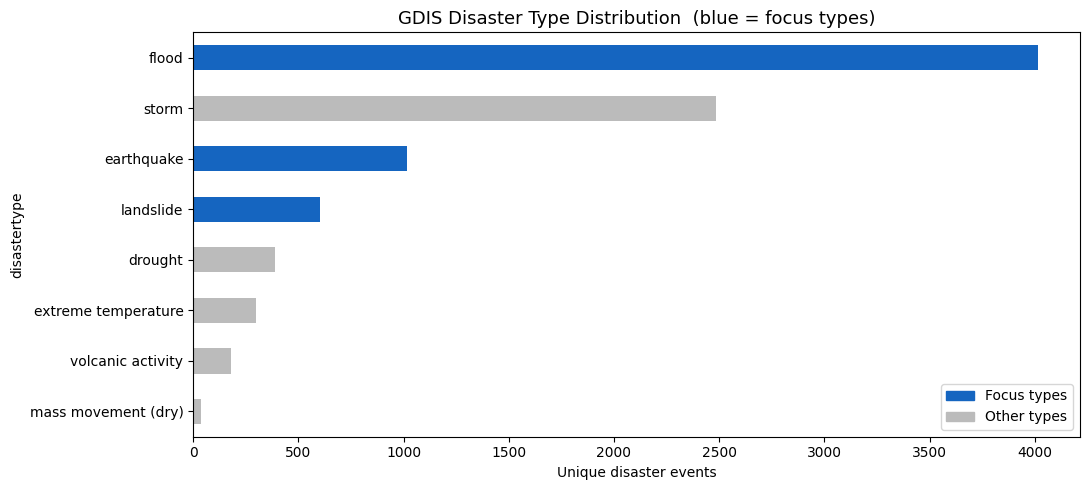

Saved → 01_type_distribution.png


In [3]:
print('=== GDIS Overview ===')
print(f'Total rows       : {len(df_loc):,}')
print(f'Unique disasters : {df_loc["disasterno"].nunique():,}')
print(f'Year range       : {int(df_loc["year"].min())} – {int(df_loc["year"].max())}')
print(f'Countries        : {df_loc["iso3"].nunique()}')

FOCUS_TYPES = {'flood','earthquake','landslide','dry mass movement','wildfire'}

type_counts = (df_loc.groupby('disastertype')['disasterno']
                     .nunique()
                     .sort_values(ascending=False))
print('\nDisaster type distribution:')
print(type_counts.to_string())

colors = ['#1565C0' if t in FOCUS_TYPES else '#BBBBBB'
          for t in type_counts.sort_values().index]
fig, ax = plt.subplots(figsize=(11, 5))
type_counts.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Unique disaster events')
ax.set_title('GDIS Disaster Type Distribution  (blue = focus types)', fontsize=13)
ax.legend(handles=[
    mpatches.Patch(color='#1565C0', label='Focus types'),
    mpatches.Patch(color='#BBBBBB', label='Other types')
])
plt.tight_layout()
plt.savefig('/kaggle/working/01_type_distribution.png', dpi=150)
plt.show()
print('Saved → 01_type_distribution.png')

In [4]:
# ════════════════════════════════════════════════════════
#  CONFIGURABLE PARAMETERS
# ════════════════════════════════════════════════════════
FOCUS_TYPES       = {'flood','earthquake','landslide','dry mass movement','wildfire'}
COUNTRY_FILTER    = None     # e.g. 'CHN' for China only, None = global
SPATIAL_RADIUS_KM = 150      # max km between disaster centroids
MIN_DISTANCE_KM   = 1.0      # drop near-zero distance country-centroid duplicates

# Year-based cascade windows
# GDIS only has year resolution — day windows are meaningless
# 0 = same year only, 1 = same or next year, 2 = up to 2 years later
TYPE_YEAR_WINDOW = {
    ('earthquake',        'landslide'):         1,
    ('earthquake',        'dry mass movement'): 1,
    ('earthquake',        'flood'):             1,
    ('earthquake',        'earthquake'):        2,   # aftershock sequences
    ('landslide',         'flood'):             1,
    ('dry mass movement', 'flood'):             1,
    ('flood',             'landslide'):         1,
    ('flood',             'dry mass movement'): 1,
    ('flood',             'flood'):             1,
    ('wildfire',          'landslide'):         1,
    ('wildfire',          'dry mass movement'): 1,
    ('wildfire',          'flood'):             1,
    ('storm',             'flood'):             1,
    ('storm',             'landslide'):         1,
    ('volcanic activity', 'landslide'):         1,
    ('volcanic activity', 'flood'):             1,
}
DEFAULT_YEAR_WINDOW = 1
# ════════════════════════════════════════════════════════

mask = df_loc['disastertype'].isin(FOCUS_TYPES)
if COUNTRY_FILTER:
    mask &= df_loc['iso3'] == COUNTRY_FILTER.upper()

df_focus = df_loc[mask].copy()
df_focus = df_focus.dropna(subset=['latitude','longitude'])

print(f'After filtering:')
print(f'  Rows             : {len(df_focus):,}')
print(f'  Unique disasters : {df_focus["disasterno"].nunique():,}')
print(f'  Types            : {sorted(df_focus["disastertype"].unique())}')

# Per-event centroid
events = (df_focus.groupby('disasterno')
                  .agg(
                      year         = ('year',         'first'),
                      disastertype = ('disastertype',  'first'),
                      iso3         = ('iso3',          'first'),
                      country      = ('country',       'first'),
                      admin1       = ('adm1',         lambda x: x.mode()[0] if len(x)>0 else ''),
                      latitude     = ('latitude',      'mean'),
                      longitude    = ('longitude',     'mean'),
                  )
                  .reset_index())

events['year']   = events['year'].astype('Int64')
events['admin1'] = events['admin1'].fillna('').str.strip()

print(f'\nUnique events after centroid aggregation: {len(events):,}')
events.head(3)

After filtering:
  Rows             : 20,732
  Unique disasters : 5,629
  Types            : ['earthquake', 'flood', 'landslide']

Unique events after centroid aggregation: 5,629


,disasterno,year,disastertype,iso3,country,admin1,latitude,longitude
0,1960-0002,1960,earthquake,IRN,Iran,Fars,27.886791,53.967226
1,1960-0007,1960,earthquake,PER,Peru,Arequipa,-15.843334,-72.476456
2,1960-0010,1960,earthquake,MAR,Morocco,Souss-Massa-Draa,30.634697,-9.548856


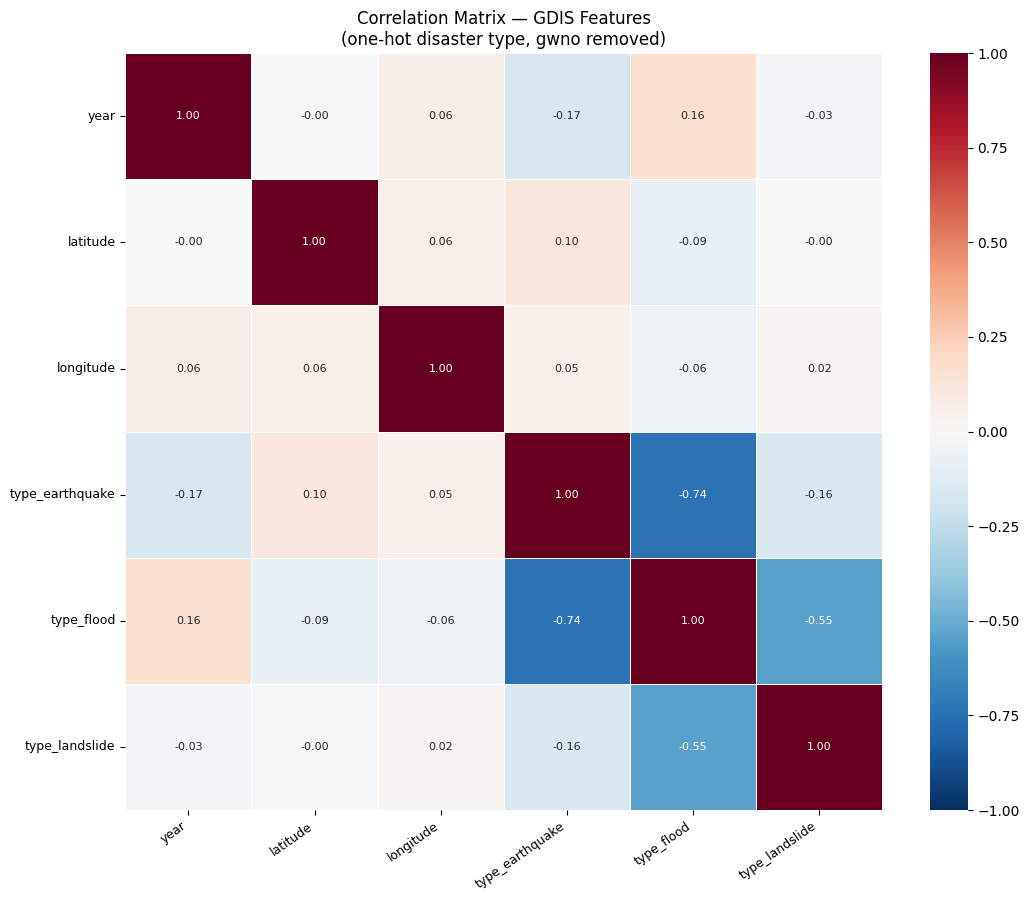

Saved → 02_correlation_matrix.png


In [5]:
# gwno dropped — it's 0.93 correlated with longitude (redundant)
# disaster type one-hot encoded (label encoding creates fake ordinal relationships)
df_corr = events[['year','latitude','longitude','disastertype']].copy()
df_corr = df_corr.dropna(subset=['year','latitude','longitude'])
ohe     = pd.get_dummies(df_corr['disastertype'], prefix='type')
df_corr = pd.concat([df_corr.drop('disastertype', axis=1), ohe], axis=1).astype(float)

# === FEATURE NORMALIZATION (USEFUL FOR TGNN) ===

events['year_norm'] = (events['year'] - events['year'].min()) / (
    events['year'].max() - events['year'].min()
)

events['lat_norm'] = (events['latitude'] - events['latitude'].min()) / (
    events['latitude'].max() - events['latitude'].min()
)

events['lon_norm'] = (events['longitude'] - events['longitude'].min()) / (
    events['longitude'].max() - events['longitude'].min()
)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — GDIS Features\n(one-hot disaster type, gwno removed)', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/02_correlation_matrix.png', dpi=150)
plt.show()
print('Saved → 02_correlation_matrix.png')

In [6]:
# ----------------------------
# Distance (Haversine)
# ----------------------------
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# ----------------------------
# Direction (numeric + cyclic)
# ----------------------------
DIRECTION_MAP = {
    'N': 0, 'NE': 1, 'E': 2, 'SE': 3,
    'S': 4, 'SW': 5, 'W': 6, 'NW': 7
}

def bearing_to_direction(lat1, lon1, lat2, lon2):
    dlon = math.radians(lon2 - lon1)

    x = math.sin(dlon) * math.cos(math.radians(lat2))
    y = (
        math.cos(math.radians(lat1)) * math.sin(math.radians(lat2))
        - math.sin(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.cos(dlon)
    )

    bearing = (math.degrees(math.atan2(x, y)) + 360) % 360
    direction = ['N','NE','E','SE','S','SW','W','NW'][int((bearing + 22.5) / 45) % 8]

    # Convert to numeric + cyclic features (for ML)
    idx = DIRECTION_MAP[direction]
    angle = (idx / 8) * 2 * np.pi

    return {
        'direction': direction,   # for KG
        'dir_idx': idx,           # optional numeric
        'dir_sin': np.sin(angle), # ML feature
        'dir_cos': np.cos(angle)
    }


# ----------------------------
# Distance Features (ML + KG)
# ----------------------------
def distance_features(km, dtype=''):
    # qualitative (KG)
    if dtype == 'earthquake':
        if km <= 20:  label = 'VeryClose'
        elif km <= 50:  label = 'Near'
        elif km <= 200: label = 'Medium'
        else: label = 'Far'
    else:
        if km < 50: label = 'Near'
        elif km < 150: label = 'Medium'
        else: label = 'Far'

    # numeric (ML)
    return {
        'distance_km': km,
        'log_distance': np.log1p(km),
        'inv_distance': 1 / (1 + km),
        'distance_label': label
    }


# ----------------------------
# Temporal Features
# ----------------------------
def temporal_features(year_delta):
    return {
        'year_delta': year_delta,
        'log_time': np.log1p(year_delta),
        'inv_time': 1 / (1 + year_delta)
    }


# ----------------------------
# Deterministic Entity Builder
# ----------------------------
def make_entity(name, etype, attrs=None):
    eid = f"{etype}_{abs(hash(name)) % 10**8}"  # stable ID
    return {
        'id': eid,
        'name': name,
        'type': etype,
        'attrs': attrs or {}
    }


print('Helper functions defined')

Helper functions defined


In [7]:
event_list = events.to_dict('records')

print('Detecting cascade pairs (year-resolution mode, v3 rules)...')
cascade_pairs = []
cascade_features = []   # 🔥 NEW (for ML later)

skipped_country   = 0
skipped_direction = 0
skipped_window    = 0
skipped_same_type = 0
skipped_spatial   = 0
skipped_zero      = 0

for i, a in enumerate(event_list):
    for b in event_list[i+1:]:

        # Same country
        if a['iso3'] != b['iso3']:
            skipped_country += 1
            continue

        # Year values
        try:
            year_a = int(a['year'])
            year_b = int(b['year'])
        except:
            continue

        year_delta = year_b - year_a

        # Direction constraint
        if year_delta < 0:
            skipped_direction += 1
            continue

        # Same-type same-year rule
        if year_delta == 0 and a['disastertype'] == b['disastertype']:
            if a['disastertype'] != 'earthquake':
                skipped_same_type += 1
                continue

        # Time window
        max_years = TYPE_YEAR_WINDOW.get(
            (a['disastertype'], b['disastertype']), DEFAULT_YEAR_WINDOW
        )
        if year_delta > max_years:
            skipped_window += 1
            continue

        # Distance
        dist = haversine(a['latitude'], a['longitude'],
                         b['latitude'], b['longitude'])

        if dist > SPATIAL_RADIUS_KM:
            skipped_spatial += 1
            continue

        if dist < MIN_DISTANCE_KM:
            skipped_zero += 1
            continue

        # Approx temporal distance
        delta_days_approx = 180 if year_delta == 0 else year_delta * 365

        # -----------------------------
        # 🔥 FEATURE EXTRACTION (NEW)
        # -----------------------------
        dist_feats = distance_features(dist, a['disastertype'])
        dir_feats  = bearing_to_direction(
            a['latitude'], a['longitude'],
            b['latitude'], b['longitude']
        )
        time_feats = temporal_features(year_delta)

        feature_dict = {
            'src': a['disasterno'],
            'dst': b['disasterno'],
            'label': 1,  # cascade

            # raw
            'distance': dist,
            'year_delta': year_delta,

            # ML features
            **dist_feats,
            **dir_feats,
            **time_feats
        }

        cascade_features.append(feature_dict)

        # Original output (unchanged)
        cascade_pairs.append((
            a['disasterno'], b['disasterno'],
            dist, delta_days_approx, year_delta
        ))

print(f'\n  Cascade pairs found      : {len(cascade_pairs):,}')
print(f'  Skipped (diff country)   : {skipped_country:,}')
print(f'  Skipped (b before a)     : {skipped_direction:,}')
print(f'  Skipped (time window)    : {skipped_window:,}')
print(f'  Skipped (same-type/year) : {skipped_same_type:,}')
print(f'  Skipped (>radius)        : {skipped_spatial:,}')
print(f'  Skipped (0km dup)        : {skipped_zero:,}')


# -----------------------------
# Chain building (UNCHANGED)
# -----------------------------
adjacency = defaultdict(set)
for a, b, _, _, _ in cascade_pairs:
    adjacency[a].add(b)
    adjacency[b].add(a)

visited = set()
chain_groups = []

def bfs(start):
    comp, queue = [], [start]
    while queue:
        node = queue.pop(0)
        if node in visited: continue
        visited.add(node)
        comp.append(node)
        queue.extend(adjacency[node] - visited)
    return comp

for node in adjacency:
    if node not in visited:
        comp = bfs(node)
        if len(comp) >= 2:
            chain_groups.append(comp)


# Lookup dicts
pair_info = {}
pair_yeardelta = {}

for a, b, dist, ddays, ydelta in cascade_pairs:
    pair_info[(a, b)] = (dist, ddays)
    pair_info[(b, a)] = (dist, ddays)
    pair_yeardelta[(a, b)] = ydelta
    pair_yeardelta[(b, a)] = ydelta

ev_row_lookup = {ev['disasterno']: ev for ev in event_list}

size_dist = Counter(len(c) for c in chain_groups)

print(f'\n  Cascade chains (≥2 events) : {len(chain_groups):,}')
print(f'  Events in chains           : {len(adjacency):,}')
print(f'\n  Chain size distribution:')
for s in sorted(size_dist):
    print(f'    {s} events : {size_dist[s]:,} chains')

Detecting cascade pairs (year-resolution mode, v3 rules)...

  Cascade pairs found      : 1,822
  Skipped (diff country)   : 15,515,284
  Skipped (b before a)     : 1
  Skipped (time window)    : 295,906
  Skipped (same-type/year) : 4,688
  Skipped (>radius)        : 21,945
  Skipped (0km dup)        : 360

  Cascade chains (≥2 events) : 583
  Events in chains           : 1,970

  Chain size distribution:
    2 events : 335 chains
    3 events : 124 chains
    4 events : 36 chains
    5 events : 34 chains
    6 events : 15 chains
    7 events : 6 chains
    8 events : 7 chains
    9 events : 3 chains
    10 events : 3 chains
    11 events : 5 chains
    12 events : 2 chains
    13 events : 2 chains
    14 events : 1 chains
    15 events : 2 chains
    16 events : 1 chains
    20 events : 1 chains
    21 events : 1 chains
    24 events : 1 chains
    29 events : 1 chains
    31 events : 1 chains
    34 events : 1 chains
    45 events : 1 chains


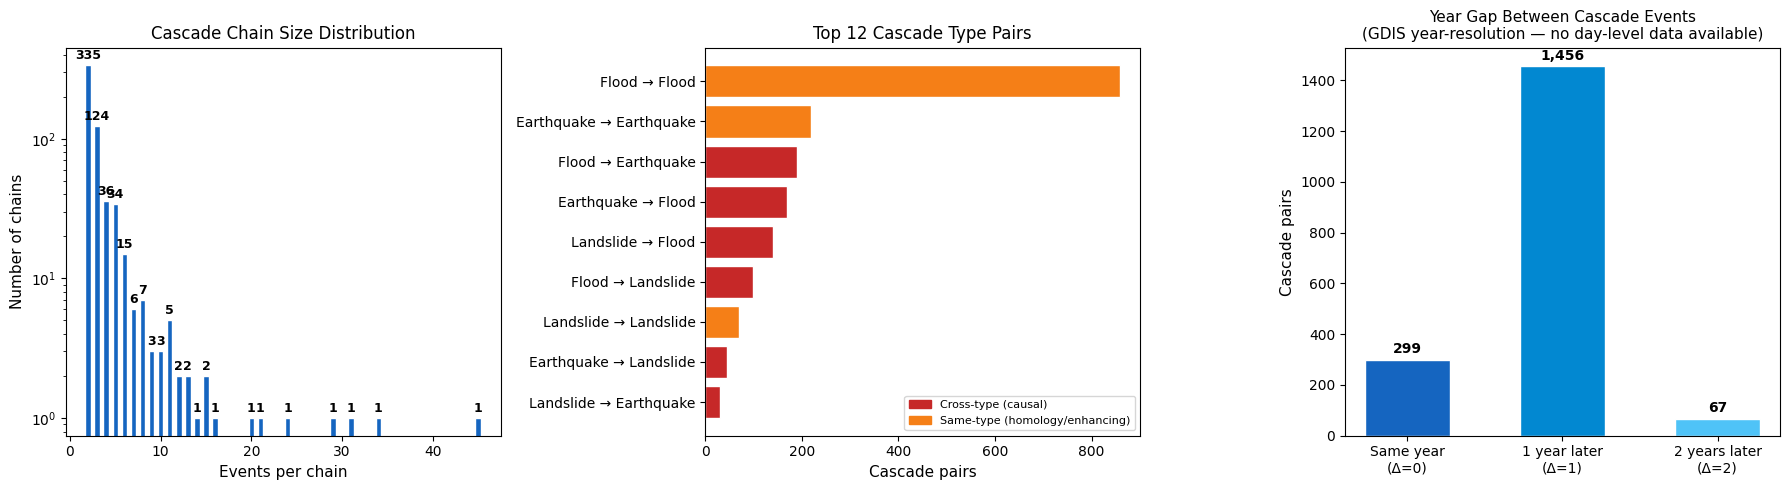

Saved → 03_cascade_eda.png


In [8]:
ev_type_map = {ev['disasterno']: ev['disastertype'] for ev in event_list}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Chain size distribution ──────────────────────────────────────────
sizes = sorted(size_dist.keys())
scnts = [size_dist[s] for s in sizes]
axes[0].bar(sizes, scnts, color='#1565C0', edgecolor='white', width=0.6)
axes[0].set_xlabel('Events per chain', fontsize=11)
axes[0].set_ylabel('Number of chains', fontsize=11)
axes[0].set_title('Cascade Chain Size Distribution', fontsize=12)
if max(scnts) / (min(scnts) + 1) > 10:
    axes[0].set_yscale('log')
for s, c in zip(sizes, scnts):
    axes[0].text(s, c * 1.05, str(c), ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

# ── Plot 2: Top 12 cascade type pairs ────────────────────────────────────────
pair_type_counts = Counter(
    f"{ev_type_map.get(a,'?').title()} → {ev_type_map.get(b,'?').title()}"
    for a, b, _, _, _ in cascade_pairs
)
top_pairs  = dict(pair_type_counts.most_common(12))
pair_colors = [
    '#C62828' if k.split(' → ')[0] != k.split(' → ')[1] else '#F57F17'
    for k in top_pairs
]
axes[1].barh(list(top_pairs.keys()), list(top_pairs.values()),
             color=pair_colors, edgecolor='white')
axes[1].set_xlabel('Cascade pairs', fontsize=11)
axes[1].set_title('Top 12 Cascade Type Pairs', fontsize=12)
axes[1].invert_yaxis()
axes[1].legend(handles=[
    mpatches.Patch(color='#C62828', label='Cross-type (causal)'),
    mpatches.Patch(color='#F57F17', label='Same-type (homology/enhancing)'),
], fontsize=8, loc='lower right')

# ── Plot 3: Year gap — categorical (v3 fix, no fake 365-day spike) ────────────
year_deltas = [yd for _, _, _, _, yd in cascade_pairs]
gap_counts  = Counter(year_deltas)
max_gap     = max(gap_counts.keys())
gap_labels  = []
gap_values  = []
for g in range(max_gap + 1):
    if g == 0:
        gap_labels.append('Same year\n(Δ=0)')
    elif g == 1:
        gap_labels.append('1 year later\n(Δ=1)')
    else:
        gap_labels.append(f'{g} years later\n(Δ={g})')
    gap_values.append(gap_counts.get(g, 0))

bar_colors = ['#1565C0','#0288D1','#4FC3F7','#B3E5FC'][:len(gap_labels)]
bars = axes[2].bar(gap_labels, gap_values, color=bar_colors,
                   edgecolor='white', width=0.55)
axes[2].set_ylabel('Cascade pairs', fontsize=11)
axes[2].set_title('Year Gap Between Cascade Events\n'
                  '(GDIS year-resolution — no day-level data available)', fontsize=11)
for bar, v in zip(bars, gap_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + max(gap_values)*0.01,
                 f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/03_cascade_eda.png', dpi=150)
plt.show()
print('Saved → 03_cascade_eda.png')

In [9]:
import random

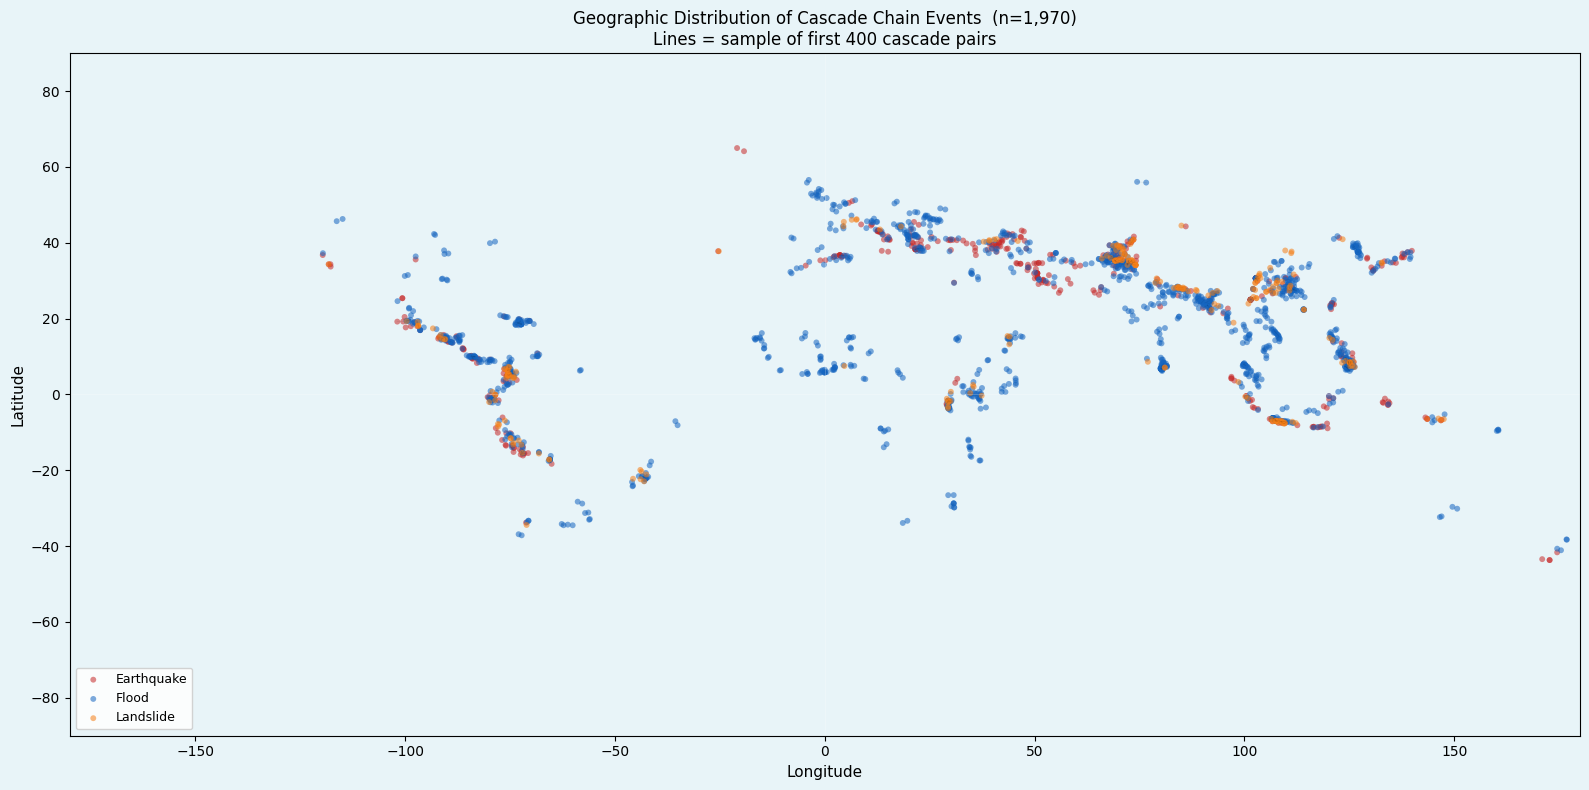

Saved → 04_cascade_map.png


In [10]:
# ── Geographic scatter of cascade events ─────────────────────────────────────
events_in_chains = set(n for chain in chain_groups for n in chain)
df_chain_ev = events[events['disasterno'].isin(events_in_chains)].copy()

TYPE_COLORS = {
    'flood':             '#1565C0',
    'earthquake':        '#C62828',
    'landslide':         '#F57F17',
    'dry mass movement': '#6A1B9A',
    'wildfire':          '#E65100',
}

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor('#E8F4F8')
fig.patch.set_facecolor('#E8F4F8')

for dtype, grp in df_chain_ev.groupby('disastertype'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=TYPE_COLORS.get(dtype, '#888888'),
               s=18, alpha=0.55, label=dtype.title(), edgecolors='none')

ev_coords = {ev['disasterno']: (ev['longitude'], ev['latitude']) for ev in event_list}

sample_pairs = random.sample(
    cascade_pairs,
    min(400, len(cascade_pairs))
)

for a, b, dist, _, _ in sample_pairs:
    if a in ev_coords and b in ev_coords:
        xa, ya = ev_coords[a]
        xb, yb = ev_coords[b]
        ax.plot([xa, xb], [ya, yb], 'k-', alpha=0.07, linewidth=0.5)



ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.axhline(0, color='white', linewidth=0.4, alpha=0.4)
ax.axvline(0, color='white', linewidth=0.4, alpha=0.4)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude',  fontsize=11)
ax.set_title(
    f'Geographic Distribution of Cascade Chain Events  (n={len(df_chain_ev):,})\n'
    f'Lines = sample of first 400 cascade pairs',
    fontsize=12
)


ax.legend(loc='lower left', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig('/kaggle/working/04_cascade_map.png', dpi=150)
plt.show()
print('Saved → 04_cascade_map.png')

In [11]:
# -----------------------------
# Mappings (unchanged)
# -----------------------------
GDIS_TO_DCER = {
    'flood':               'Flood',
    'earthquake':          'Earthquake',
    'landslide':           'Landslide',
    'dry mass movement':   'Landslide',
    'wildfire':            'ForestFire',
    'storm':               'Storm',
    'volcanic activity':   'VolcanicActivity',
    'extreme temperature': 'ExtremeTemperature',
    'drought':             'Drought',
}

CAUSE_FACTOR_MAP = {
    'flood':               'Extreme rainfall / river overflow',
    'earthquake':          'Tectonic fault rupture',
    'landslide':           'Slope instability (rainfall or seismic)',
    'dry mass movement':   'Slope instability (dry conditions)',
    'wildfire':            'Drought + high temperature + wind',
    'storm':               'Atmospheric cyclonic system',
    'volcanic activity':   'Magmatic or geothermal activity',
    'extreme temperature': 'Anomalous heat or cold event',
    'drought':             'Prolonged precipitation deficit',
}

# -----------------------------
# Deterministic encoding maps (NEW)
# -----------------------------
TYPE_TO_IDX  = {t:i for i, t in enumerate(GDIS_TO_DCER.keys())}
CAUSE_TO_IDX = {c:i for i, c in enumerate(set(CAUSE_FACTOR_MAP.values()))}

# -----------------------------
# Entity extraction (FIXED)
# -----------------------------
def extract_entities(ev_row):
    dtype   = ev_row['disastertype']
    dclass  = GDIS_TO_DCER.get(dtype, dtype.title())
    disno   = ev_row['disasterno']
    country = str(ev_row.get('country', ''))
    admin1  = str(ev_row.get('admin1',  ''))
    year    = ev_row.get('year', None)

    lat = ev_row.get('latitude', 0.0)
    lon = ev_row.get('longitude', 0.0)

    # FIX: clean location formatting
    loc_str = ", ".join(filter(None, [admin1, country]))

    cause = CAUSE_FACTOR_MAP.get(dtype, 'Unknown triggering factor')

    # Extract one-hot type columns if present
    # Extract one-hot type columns if present
    type_cols = [c for c in ev_row.keys() if c.startswith('type_')]
    type_vector = {c: ev_row[c] for c in type_cols} if type_cols else {}
    type_vector = {c: ev_row[c] for c in type_cols} if type_cols else {}

    return [
        # -------------------------
        # Disaster Event
        # -------------------------
        make_entity(
            f"{dclass} in {loc_str} ({year})",
            'DisasterEvent',
            {
                'disasterno': disno,
                'disastertype': dtype,
                'dcer_class': dclass,

                # 🔥 NUMERIC FEATURES (important)
                'type_idx': TYPE_TO_IDX.get(dtype, -1),
                'cause_idx': CAUSE_TO_IDX.get(cause, -1),

                # optional OHE
                'type_vector': type_vector,

                'year': int(year) if pd.notna(year) else None,
                'country': country,
                'admin1': admin1,
            },
        ),

        # -------------------------
        # Geological Environment
        # -------------------------
        make_entity(
            loc_str or country,
            'GeologicalEnvironment',
            {
                'latitude': round(lat, 4),
                'longitude': round(lon, 4),

                # 🔥 normalized features (important)
                'lat_norm': ev_row.get('lat_norm'),
                'lon_norm': ev_row.get('lon_norm'),

                'admin1': admin1,
                'country': country,
                'iso3': ev_row.get('iso3', ''),
            },
        ),

        # -------------------------
        # Disaster Attributes
        # -------------------------
        make_entity(
            f"Attributes of {dclass} {disno}",
            'DisasterAttribute',
            {
                'disasterno': disno,
                'year': int(year) if pd.notna(year) else None,

                # FIX: proper coordinate format
                'coordinates': f"{lat:.4f},{lon:.4f}",

                'location': loc_str,
                'source': 'GDIS/EM-DAT',
            },
        ),

        # -------------------------
        # Cause Factor
        # -------------------------
        make_entity(
            cause,
            'DisasterCausingFactor',
            {
                'type': 'hazard factor',
                'inferred_from': dtype,

                # 🔥 numeric encoding
                'cause_idx': CAUSE_TO_IDX.get(cause, -1),
            },
        ),
    ]


# -----------------------------
# Build entity map
# -----------------------------
print('Extracting entities...')
entity_map = {ev['disasterno']: extract_entities(ev) for ev in event_list}

total_ents = sum(len(v) for v in entity_map.values())
print(f'  Total entities : {total_ents:,}  (4 per event)')

print(f'\nSample (first event):')
for e in list(entity_map.values())[2]:
    print(f'  [{e["type"]}] {e["name"]}')

Extracting entities...
  Total entities : 22,516  (4 per event)

Sample (first event):
  [DisasterEvent] Earthquake in Souss-Massa-Draa, Morocco (1960)
  [GeologicalEnvironment] Souss-Massa-Draa, Morocco
  [DisasterAttribute] Attributes of Earthquake 1960-0010
  [DisasterCausingFactor] Tectonic fault rupture


In [12]:
# ── Cell 9b: Intra-event triples ─────────────────────────────────────────────

def intra_event_triples(ev_row):

    ents = entity_map.get(ev_row['disasterno'], [])
    if not ents:
        return []

    dtype  = ev_row['disastertype']
    year   = ev_row.get('year', '')
    admin1 = ev_row.get('admin1', '')
    country= ev_row.get('country', '')

    def get(etype):
        return next(e for e in ents if e['type'] == etype)

    ev_ent  = get('DisasterEvent')
    geo     = get('GeologicalEnvironment')
    attr    = get('DisasterAttribute')
    cause   = get('DisasterCausingFactor')

    def t(head, rel, tail, conf, evidence):
        return {
            'id': f"{head['id']}_{rel}_{tail['id']}",  # deterministic

            'head': {
                'id': head['id'],
                'name': head['name'],
                'type': head['type'],
                'attrs': head.get('attrs', {})
            },

            'relation': rel,

            'tail': {
                'id': tail['id'],
                'name': tail['name'],
                'type': tail['type'],
                'attrs': tail.get('attrs', {})
            },

            'confidence': conf,
            'evidence': evidence,

            'relation_type': {
                'CausalRelation': 0,
                'SubordinateRelation': 1,
                'Spatial_Contains': 2
            }.get(rel, -1),

            'source': 'GDIS_intra_event',
            'disasterno_head': ev_row['disasterno'],
            'disasterno_tail': ev_row['disasterno'],
        }

    # ✅ IMPORTANT: return triples list
    return [
        t(cause, 'CausalRelation', ev_ent, 0.85,
          f"{cause['name']} is inferred for {dtype} in {admin1}, {country} ({year})"),

        t(attr, 'SubordinateRelation', ev_ent, 1.0,
          "Attribute belongs to DisasterEvent"),

        t(geo, 'Spatial_Contains', ev_ent, 0.90,
          f"{admin1}, {country} contains disaster location"),

        t(geo, 'CausalRelation', cause, 0.75,
          f"Environment enables {cause['name']}"),
    ]


# -----------------------------
# Build triples
# -----------------------------
print('Building intra-event triples for all events...')

all_intra_triples = []
for ev_row in event_list:
    all_intra_triples.extend(intra_event_triples(ev_row))


# -----------------------------
# 🔥 FEATURE MAP (CRITICAL PART)
# -----------------------------
event_feature_map = {}

for ev in event_list:
    disno = ev['disasterno']
    ents = entity_map[disno]

    ev_ent = next(e for e in ents if e['type'] == 'DisasterEvent')
    geo    = next(e for e in ents if e['type'] == 'GeologicalEnvironment')

    event_feature_map[disno] = {
        'type_idx': ev_ent['attrs'].get('type_idx', -1),
        'cause_idx': ev_ent['attrs'].get('cause_idx', -1),
        'lat_norm': geo['attrs'].get('lat_norm'),
        'lon_norm': geo['attrs'].get('lon_norm'),
    }


print(f'  Intra-event triples: {len(all_intra_triples):,}')
print(f'  (4 triples × {len(event_list):,} events)')

print('\nSample intra-event triples:')
for t in all_intra_triples[:4]:
    print(f"[{t['head']['type']}] {t['head']['name']}")
    print(f"  ──{t['relation']}──►")
    print(f"[{t['tail']['type']}] {t['tail']['name']}")
    print()

Building intra-event triples for all events...
  Intra-event triples: 22,516
  (4 triples × 5,629 events)

Sample intra-event triples:
[DisasterCausingFactor] Tectonic fault rupture
  ──CausalRelation──►
[DisasterEvent] Earthquake in Fars, Iran (1960)

[DisasterAttribute] Attributes of Earthquake 1960-0002
  ──SubordinateRelation──►
[DisasterEvent] Earthquake in Fars, Iran (1960)

[GeologicalEnvironment] Fars, Iran
  ──Spatial_Contains──►
[DisasterEvent] Earthquake in Fars, Iran (1960)

[GeologicalEnvironment] Fars, Iran
  ──CausalRelation──►
[DisasterCausingFactor] Tectonic fault rupture



In [13]:
CAUSAL_RULES = {
    ('earthquake',        'landslide'):           'CausalRelation',
    ('earthquake',        'dry mass movement'):   'CausalRelation',
    ('earthquake',        'flood'):               'CausalRelation',
    ('landslide',         'flood'):               'CausalRelation',
    ('dry mass movement', 'flood'):               'CausalRelation',
    ('flood',             'landslide'):           'CausalRelation',
    ('flood',             'dry mass movement'):   'CausalRelation',
    ('storm',             'flood'):               'CausalRelation',
    ('storm',             'landslide'):           'CausalRelation',
    ('volcanic activity', 'landslide'):           'CausalRelation',
    ('volcanic activity', 'flood'):               'CausalRelation',
    ('wildfire',          'landslide'):           'CausalRelation',
    ('wildfire',          'dry mass movement'):   'CausalRelation',
    ('wildfire',          'flood'):               'CausalRelation',
    ('earthquake',        'earthquake'):          'EnhancingRelation',
    ('flood',             'flood'):               'EnhancingRelation',
    ('landslide',         'landslide'):           'HomologyRelation',
    ('dry mass movement', 'dry mass movement'):   'HomologyRelation',
    ('drought',           'wildfire'):            'CausalRelation',
    ('extreme temperature','wildfire'):           'UrgeRelation',
}

def infer_relations(ev_a, ev_b, dist_km, delta_days, year_delta):
    triples = []
    dno_a, dno_b = ev_a['disasterno'], ev_b['disasterno']
    ents_a, ents_b = entity_map[dno_a], entity_map[dno_b]

    def get(ents, etype):
        return next(e for e in ents if e['type'] == etype)

    ev_ent_a = get(ents_a, 'DisasterEvent')
    ev_ent_b = get(ents_b, 'DisasterEvent')
    geo_a    = get(ents_a, 'GeologicalEnvironment')
    geo_b    = get(ents_b, 'GeologicalEnvironment')
    attr_a   = get(ents_a, 'DisasterAttribute')
    cause_a  = get(ents_a, 'DisasterCausingFactor')
    dtype_a  = ev_a['disastertype']
    dtype_b  = ev_b['disastertype']
    admin_a  = ev_a.get('admin1',  '')
    country_a= ev_a.get('country', '')

    def tri(head, rel, tail, conf, evidence):
        return {
            'id':              uuid.uuid4().hex[:12],
            'head':            {'id': head['id'], 'name': head['name'], 'type': head['type']},
            'relation':        rel,
            'tail':            {'id': tail['id'], 'name': tail['name'], 'type': tail['type']},
            'confidence':      round(conf, 3),
            'evidence':        evidence,
            'source':          'GDIS_spatiotemporal_inference',
            'disasterno_head': dno_a,
            'disasterno_tail': dno_b,
        }

    # ── 1. SEMANTIC (Shang et al. 2025 Table 3) ───────────────────────────────
    sem_rel = CAUSAL_RULES.get((dtype_a, dtype_b))
    if sem_rel:
        # Confidence: same year > 1 year gap; closer > farther
        base_conf = 0.90 if year_delta == 0 else 0.75 if year_delta == 1 else 0.60
        dist_factor = 1.0 if dist_km <= 50 else 0.92 if dist_km <= 100 else 0.84
        conf = base_conf * dist_factor
        evidence = (
            f"{dtype_a.title()} (GDIS:{dno_a}) in {admin_a}, {country_a} "
            f"preceded {dtype_b.title()} (GDIS:{dno_b}) — "
            f"year gap Δ={year_delta}, distance {dist_km:.1f}km — "
            f"country-level spatiotemporal co-occurrence "
            f"(GDIS doi:10.7927/zz3b-8y61; year resolution only)"
        )
        triples.append(tri(ev_ent_a, sem_rel, ev_ent_b, conf, evidence))

    # Causing factor → event
    triples.append(tri(
        cause_a, 'CausalRelation', ev_ent_a, 0.85,
        f"Inferred causing factor for {dtype_a} per GDIS classification"
    ))

    # SubordinateRelation
    chain_node = make_entity(
        f"Cascade chain: {dtype_a.title()}→{dtype_b.title()} "
        f"in {admin_a}, {country_a} ({ev_a.get('year','')})",
        'DisasterEvent',
        {'type': 'cascade_chain_node'},
    )
    triples.append(tri(ev_ent_a, 'SubordinateRelation', chain_node, 0.90,
                       "Event A belongs to detected cascade chain"))
    triples.append(tri(ev_ent_b, 'SubordinateRelation', chain_node, 0.90,
                       "Event B belongs to detected cascade chain"))
    triples.append(tri(attr_a, 'SubordinateRelation', ev_ent_a, 1.0,
                       "Attribute entity belongs to DisasterEvent (Shang2025 Eq.1)"))

    # ── 2. TEMPORAL (Shang et al. 2025 Table 1) ───────────────────────────────
    if year_delta == 0:
        temp_rel = 'Temporal_CoStarting'
        temp_ev  = f"Both disasters in same year ({ev_a['year']}) — GDIS year-resolution"
    elif year_delta == 1:
        temp_rel = 'Temporal_Connect'
        temp_ev  = f"Event B in year following Event A — rapid cascade (Δ=1 year)"
    else:
        temp_rel = 'Temporal_Disjoint'
        temp_ev  = f"Event B occurs {year_delta} years after Event A — delayed cascade"

    triples.append(tri(ev_ent_a, temp_rel, ev_ent_b, 0.80, temp_ev))

    # ── 3. SPATIAL (Shang et al. 2025 Table 2 + Sec 3.2.2) ───────────────────
    dlabel    = distance_label(dist_km, dtype_a)
    dist_node = make_entity(
        f"Distance {dist_km:.1f}km ({dlabel}) [{dno_a}↔{dno_b}]",
        'GeologicalEnvironment',
        {'distance_km': round(dist_km,1), 'label': dlabel},
    )
    triples.append(tri(
        geo_a, 'Spatial_Distance', dist_node, 1.0,
        f"Centroid distance {dist_km:.1f}km → {dlabel} (Shang2025 Sec3.2.2)"
    ))

    direction = bearing_to_direction(
        ev_a['latitude'], ev_a['longitude'],
        ev_b['latitude'], ev_b['longitude']
    )
    triples.append(tri(
        geo_b, 'Spatial_Direction', geo_a, 1.0,
        f"{dtype_b.title()} location is {direction} of {dtype_a.title()} location (GDIS coords)"
    ))

    if dist_km <= 50:
        triples.append(tri(
            geo_a, 'Spatial_Adjacent', geo_b, 0.90,
            f"Centroids {dist_km:.1f}km apart → Spatial_Adjacent (<50km threshold)"
        ))

    return triples

# 🔥 Convert triples → feature vector
def triples_to_features(triples):

    feats = {
        'has_causal_relation': 0,
        'causal_strength': 0,

        'temporal_type': -1,

        'has_spatial_adjacent': 0,
        'spatial_score': 0,

        'avg_confidence': 0,
        'num_relations': len(triples),
    }

    if not triples:
        return feats

    total_conf = 0

    for t in triples:
        rel = t['relation']
        conf = t['confidence']
        total_conf += conf

        # ---- causal ----
        if rel == 'CausalRelation':
            feats['has_causal_relation'] = 1
            feats['causal_strength'] = max(feats['causal_strength'], conf)

        # ---- temporal ----
        if rel == 'Temporal_CoStarting':
            feats['temporal_type'] = 0
        elif rel == 'Temporal_Connect':
            feats['temporal_type'] = 1
        elif rel == 'Temporal_Disjoint':
            feats['temporal_type'] = 2

        # ---- spatial ----
        if rel == 'Spatial_Adjacent':
            feats['has_spatial_adjacent'] = 1
            feats['spatial_score'] = 1

    feats['avg_confidence'] = total_conf / len(triples)

    return feats
    
print('✅ Relation inference ready')
print(f'   Causal rules: {len(CAUSAL_RULES)}')

✅ Relation inference ready
   Causal rules: 20


In [14]:
def distance_label(km, dtype):
    if dtype == 'earthquake':
        if km <= 20: return 'VeryClose'
        elif km <= 50: return 'Near'
        elif km <= 200: return 'Medium'
        else: return 'Far'
    else:
        if km < 50: return 'Near'
        elif km < 150: return 'Medium'
        else: return 'Far'

In [15]:
all_triples = []
chain_docs  = []

print(f'🚀 Building {len(chain_groups)} chain documents...')

for chain_idx, chain_nodes in enumerate(chain_groups):
    chain_id = f'GDIS_CHAIN_{chain_idx+1:05d}'

    # ---- get and sort events ----
    chain_events = [ev_row_lookup[n] for n in chain_nodes if n in ev_row_lookup]
    chain_events.sort(key=lambda x: x.get('year', 0))
    if not chain_events:
        continue

    # ---- collect entities ----
    chain_entities = []
    for ev in chain_events:
        chain_entities.extend(entity_map.get(ev['disasterno'], []))

    # ---- build triples ----
    chain_triples = []

    for i, ev_a in enumerate(chain_events):
        for ev_b in chain_events[i+1:]:

            key = (ev_a['disasterno'], ev_b['disasterno'])
            if key not in pair_info:
                continue

            dist_km, ddays = pair_info[key]
            ydelta         = pair_yeardelta.get(key, 0)

            # 🔥 CORE KG INTEGRATION
            ts = infer_relations(ev_a, ev_b, dist_km, ddays, ydelta)

            for t in ts:
                t['chain_id'] = chain_id

            # add to both
            chain_triples.extend(ts)
            all_triples.extend(ts)

    # ---- build readable chain sequence ----
    chain_sequence = [
        f"{GDIS_TO_DCER.get(ev['disastertype'], ev['disastertype'].title())} "
        f"in {ev.get('admin1','')}, {ev.get('country','')} ({ev['year']})"
        for ev in chain_events
    ]

    # ---- store chain document ----
    chain_docs.append({
        'chain_id':       chain_id,
        'n_events':       len(chain_events),
        'disaster_types': list({ev['disastertype'] for ev in chain_events}),
        'countries':      list({ev.get('country','') for ev in chain_events}),
        'year_range':     [
            int(chain_events[0]['year']),
            int(chain_events[-1]['year'])
        ],
        'chain_sequence': chain_sequence,
        'disasternos':    [ev['disasterno'] for ev in chain_events],
        'entities':       chain_entities,
        'triples':        chain_triples,
        'n_entities':     len(chain_entities),
        'n_triples':      len(chain_triples),
        'source':         'GDIS (Rosvold & Buhaug 2021)',
        'schema':         'DCER-MC (Shang et al. 2025)',
    })

# ---- final summary ----
print(f'\n✅ DONE')
print(f'   Chain documents : {len(chain_docs):,}')
print(f'   Total triples   : {len(all_triples):,}')

# ---- sample output ----
if chain_docs:
    c = chain_docs[0]
    print(f'\n🔎 First chain: {c["chain_id"]}')
    print(f'   Types: {c["disaster_types"]}')
    print(f'   Sequence:')
    for s in c['chain_sequence']:
        print(f'     → {s}')

🚀 Building 583 chain documents...

✅ DONE
   Chain documents : 583
   Total triples   : 14,749

🔎 First chain: GDIS_CHAIN_00001
   Types: ['flood']
   Sequence:
     → Flood in North, Hong Kong (1960)
     → Flood in North, Hong Kong (1961)


DCER-MC DATASET STATISTICS  (v3)
Source   : GDIS (Rosvold & Buhaug 2021)
Schema   : DCER-MC (Shang et al. 2025)
Matching : country-level + 150km radius
Window   : year-based (type-specific, 1–2 years)
Same-type same-year: excluded (except EQ aftershocks)

Chain docs   : 583
Entities     : 7,880
Triples      : 14,749
Avg conf     : 0.896

Relation distribution:
  SubordinateRelation                   5,466  ██████████████████████████████
  CausalRelation                        2,291  ████████████
  Spatial_Distance                      1,822  ██████████
  Spatial_Direction                     1,822  ██████████
  Temporal_Connect                      1,456  ███████
  EnhancingRelation                     1,078  █████
  Spatial_Adjacent                        378  ██
  Temporal_CoStarting                     299  █
  HomologyRelation                         70  
  Temporal_Disjoint                        67  


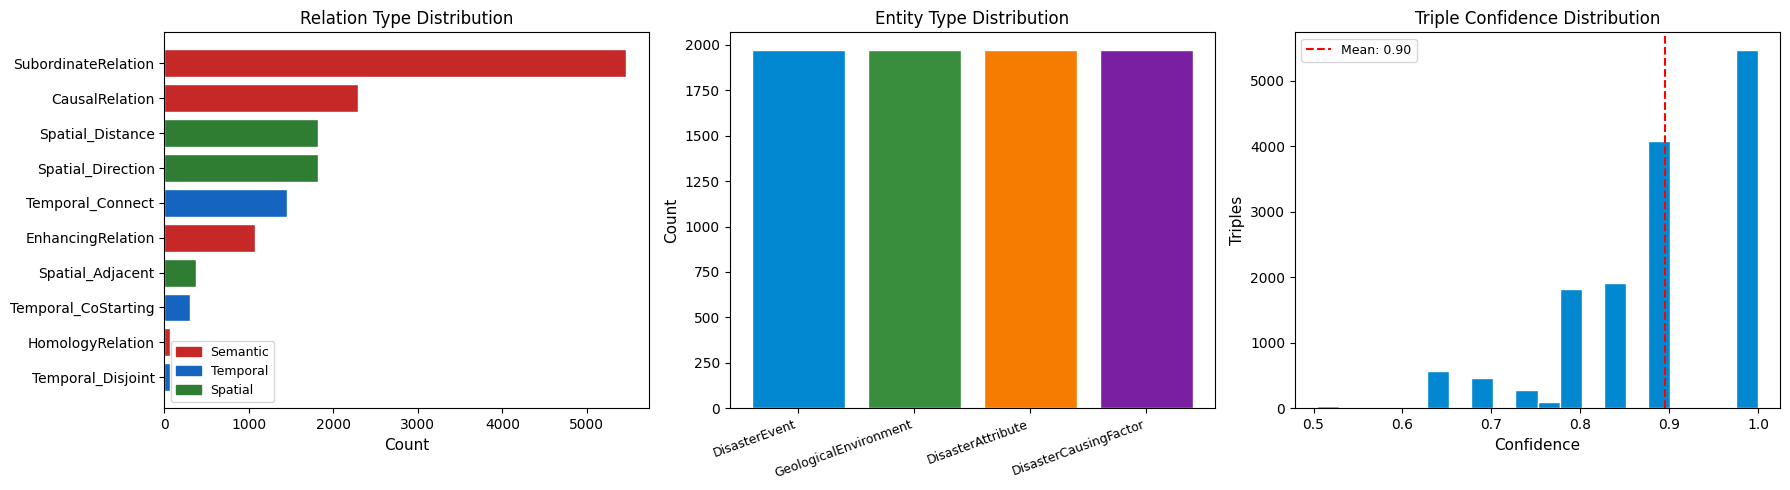

Saved → 05_dcer_mc_stats.png


In [16]:

rel_dist   = Counter(t['relation'] for t in all_triples)
etype_dist = Counter(e['type'] for c in chain_docs for e in c['entities'])
dtype_dist = Counter(dt for c in chain_docs for dt in c['disaster_types'])
conf_vals  = [t['confidence'] for t in all_triples]

print('=' * 56)
print('DCER-MC DATASET STATISTICS  (v3)')
print('=' * 56)
print(f'Source   : GDIS (Rosvold & Buhaug 2021)')
print(f'Schema   : DCER-MC (Shang et al. 2025)')
print(f'Matching : country-level + {SPATIAL_RADIUS_KM}km radius')
print(f'Window   : year-based (type-specific, 1–2 years)')
print(f'Same-type same-year: excluded (except EQ aftershocks)')
print()
print(f'Chain docs   : {len(chain_docs):,}')
print(f'Entities     : {sum(c["n_entities"] for c in chain_docs):,}')
print(f'Triples      : {len(all_triples):,}')
print(f'Avg conf     : {np.mean(conf_vals):.3f}')
print()
print('Relation distribution:')
for rel, cnt in rel_dist.most_common():
    bar = '█' * (cnt * 30 // max(rel_dist.values()))
    print(f'  {rel:<35} {cnt:>7,}  {bar}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rels   = [r for r, _ in rel_dist.most_common()]
rcnts  = [c for _, c in rel_dist.most_common()]
rcolors = [
    '#C62828' if any(x in r for x in ['Causal','Urge','Enhancing','Homology','Subordinate'])
    else '#1565C0' if 'Temporal' in r
    else '#2E7D32'
    for r in rels
]
axes[0].barh(rels[::-1], rcnts[::-1], color=rcolors[::-1], edgecolor='white')
axes[0].set_xlabel('Count', fontsize=11)
axes[0].set_title('Relation Type Distribution', fontsize=12)
axes[0].legend(handles=[
    mpatches.Patch(color='#C62828', label='Semantic'),
    mpatches.Patch(color='#1565C0', label='Temporal'),
    mpatches.Patch(color='#2E7D32', label='Spatial'),
], fontsize=9)

etypes = [et for et, _ in etype_dist.most_common()]
ecnts  = [c  for _,  c in etype_dist.most_common()]
ec     = ['#0288D1','#388E3C','#F57C00','#7B1FA2'][:len(etypes)]
axes[1].bar(range(len(etypes)), ecnts, color=ec, edgecolor='white')
axes[1].set_xticks(range(len(etypes)))
axes[1].set_xticklabels(etypes, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Entity Type Distribution', fontsize=12)

axes[2].hist(conf_vals, bins=20, color='#0288D1', edgecolor='white')
axes[2].axvline(np.mean(conf_vals), color='red', linestyle='--',
                label=f'Mean: {np.mean(conf_vals):.2f}')
axes[2].set_xlabel('Confidence', fontsize=11)
axes[2].set_ylabel('Triples',    fontsize=11)
axes[2].set_title('Triple Confidence Distribution', fontsize=12)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/05_dcer_mc_stats.png', dpi=150)
plt.show()
print('Saved → 05_dcer_mc_stats.png')

In [17]:
print("Generating candidate event pairs...")

candidate_pairs = []

for i, a in enumerate(event_list):
    for b in event_list:

        if a['disasterno'] == b['disasterno']:
            continue

        # ---- temporal ----
        try:
            year_a = int(a['year'])
            year_b = int(b['year'])
        except:
            continue

        year_delta = year_b - year_a

        if year_delta < 0:
            continue

        # ---- spatial ----
        dist = haversine(
            a['latitude'], a['longitude'],
            b['latitude'], b['longitude']
        )

        # ---- build pair ----
        pair = {
            'src': a['disasterno'],
            'dst': b['disasterno'],
            'distance': dist,
            'year_delta': year_delta,
        }

        candidate_pairs.append(pair)

print(f"✅ Total candidate pairs: {len(candidate_pairs):,}")

Generating candidate event pairs...
✅ Total candidate pairs: 16,250,937


In [18]:
print('Building final training dataset...')

cascade_set = set((a, b) for a, b, *_ in cascade_pairs)

final_data = []

for pair in candidate_pairs:

    a_id = pair['src']
    b_id = pair['dst']

    # ---- label ----
    label = 1 if (a_id, b_id) in cascade_set else 0

    # ---- geometry features ----
    dist = pair['distance']
    year_delta = pair['year_delta']

    dist_feats = distance_features(dist)
    time_feats = temporal_features(year_delta)

    dir_feats = bearing_to_direction(
        ev_row_lookup[a_id]['latitude'],
        ev_row_lookup[a_id]['longitude'],
        ev_row_lookup[b_id]['latitude'],
        ev_row_lookup[b_id]['longitude']
    )

    # ---- event-level features ----
    fa = event_feature_map.get(a_id, {})
    fb = event_feature_map.get(b_id, {})

    # ---- combine ----
    features = {
        # geometry
        **dist_feats,
        **time_feats,
        **dir_feats,

        # semantic
        'type_diff': abs(fa.get('type_idx', 0) - fb.get('type_idx', 0)),
        'cause_diff': abs(fa.get('cause_idx', 0) - fb.get('cause_idx', 0)),

        'lat_diff': abs((fa.get('lat_norm') or 0) - (fb.get('lat_norm') or 0)),
        'lon_diff': abs((fa.get('lon_norm') or 0) - (fb.get('lon_norm') or 0)),
    }

    final_data.append({
        'src': a_id,
        'dst': b_id,
        'features': features,
        'label': label
    })

print(f'✅ Final dataset size: {len(final_data):,}')

Building final training dataset...
✅ Final dataset size: 16,250,937


In [19]:

OUT = '/kaggle/working'

# 1. Flat triples JSONL
triples_path = f'{OUT}/dcer_mc_from_gdis_triples.jsonl'
with open(triples_path, 'w', encoding='utf-8') as f:
    for t in all_triples:
        f.write(json.dumps(t, ensure_ascii=False) + '\n')
print(f'✅ Triples    : {triples_path}  ({len(all_triples):,} lines)')

# 2. Chain documents JSONL
chains_path = f'{OUT}/dcer_mc_from_gdis_chains.jsonl'
with open(chains_path, 'w', encoding='utf-8') as f:
    for c in chain_docs:
        f.write(json.dumps(c, ensure_ascii=False) + '\n')
print(f'✅ Chains     : {chains_path}  ({len(chain_docs):,} lines)')

# 3. Events CSV
events_in_chains = set(n for chain in chain_groups for n in chain)
df_chain_ev = events[events['disasterno'].isin(events_in_chains)].copy()
df_chain_ev['dcer_class'] = df_chain_ev['disastertype'].map(GDIS_TO_DCER)
csv_path = f'{OUT}/dcer_mc_from_gdis_events.csv'
df_chain_ev.to_csv(csv_path, index=False)
print(f'✅ Events CSV : {csv_path}  ({len(df_chain_ev):,} rows)')

# 4. Stats JSON
stats = {
    'version':        'v3',
    'source_dataset': 'GDIS (Rosvold & Buhaug 2021) doi:10.7927/zz3b-8y61',
    'schema':         'DCER-MC (Shang et al. 2025) Electronics 14, 4951',
    'pipeline_params': {
        'country_filter':          COUNTRY_FILTER or 'ALL',
        'focus_types':             list(FOCUS_TYPES),
        'spatial_radius_km':       SPATIAL_RADIUS_KM,
        'min_distance_km':         MIN_DISTANCE_KM,
        'temporal_resolution':     'year (GDIS limitation — no day-level data)',
        'type_year_windows':       {str(k): v for k, v in TYPE_YEAR_WINDOW.items()},
        'same_type_same_year':     'excluded except earthquake→earthquake (aftershocks)',
    },
    'dataset_stats': {
        'total_gdis_rows':   len(df_loc),
        'filtered_rows':     len(df_focus),
        'unique_events':     len(events),
        'cascade_pairs':     len(cascade_pairs),
        'cascade_chains':    len(chain_docs),
        'total_entities':    sum(c['n_entities'] for c in chain_docs),
        'total_triples':     len(all_triples),
        'mean_confidence':   round(float(np.mean(conf_vals)), 3),
    },
    'relation_distribution':      dict(rel_dist.most_common()),
    'entity_type_distribution':   dict(etype_dist.most_common()),
    'disaster_type_distribution': dict(dtype_dist.most_common()),
    'chain_size_distribution':    dict(Counter(c['n_events'] for c in chain_docs).most_common()),
    'methodology_note': (
        'GDIS provides year-level temporal resolution only. Cascade pairs are '
        'classified by year gap (Δ=0: same year, Δ=1: consecutive years, Δ=2: '
        'two-year gap) rather than exact day intervals. Same-type same-year pairs '
        'are excluded to avoid false positives (e.g. two independent annual floods '
        'in the same country), except for earthquake→earthquake pairs which represent '
        'valid aftershock sequences. This is a known limitation of the GDIS dataset '
        'as noted by Rosvold & Buhaug (2021).'
    ),
}
stats_path = f'{OUT}/dcer_mc_from_gdis_stats.json'
with open(stats_path, 'w') as f:
    json.dump(stats, f, indent=2)
print(f'✅ Stats      : {stats_path}')

print('\n' + '='*56)
print('ALL FILES SAVED TO /kaggle/working/')
print('='*56)
print(json.dumps(stats['dataset_stats'], indent=2))

✅ Triples    : /kaggle/working/dcer_mc_from_gdis_triples.jsonl  (14,749 lines)
✅ Chains     : /kaggle/working/dcer_mc_from_gdis_chains.jsonl  (583 lines)
✅ Events CSV : /kaggle/working/dcer_mc_from_gdis_events.csv  (1,970 rows)
✅ Stats      : /kaggle/working/dcer_mc_from_gdis_stats.json

ALL FILES SAVED TO /kaggle/working/
{
  "total_gdis_rows": 39953,
  "filtered_rows": 20732,
  "unique_events": 5629,
  "cascade_pairs": 1822,
  "cascade_chains": 583,
  "total_entities": 7880,
  "total_triples": 14749,
  "mean_confidence": 0.896
}


In [20]:
print("🚀 Building FINAL dataset (optimized)...")

import random

# -----------------------------
# CONFIG (tune if needed)
# -----------------------------
MAX_NEG_PER_POS = 3   # balance dataset
MAX_DISTANCE_KM = 500  # restrict search space

# -----------------------------
# Build positive set
# -----------------------------
cascade_set = set((a, b) for a, b, *_ in cascade_pairs)

# -----------------------------
# Build index for fast lookup
# -----------------------------
event_lookup = {ev['disasterno']: ev for ev in event_list}

# -----------------------------
# FINAL DATA
# -----------------------------
final_data = []

neg_count = 0
pos_count = 0

for pair in candidate_pairs:

    a_id = pair['src']
    b_id = pair['dst']

    dist = pair['distance']
    year_delta = pair['year_delta']

    # ---- filter (IMPORTANT for performance) ----
    if dist > MAX_DISTANCE_KM:
        continue

    if year_delta > 3:
        continue

    # ---- label ----
    label = 1 if (a_id, b_id) in cascade_set else 0

    # ---- balance dataset ----
    if label == 0 and neg_count > MAX_NEG_PER_POS * max(1, pos_count):
        continue

    # ---- geometry features ----
    dist_feats = distance_features(dist)
    time_feats = temporal_features(year_delta)

    ev_a = event_lookup[a_id]
    ev_b = event_lookup[b_id]

    dir_feats = bearing_to_direction(
        ev_a['latitude'], ev_a['longitude'],
        ev_b['latitude'], ev_b['longitude']
    )

    # ---- event-level KG features ----
    fa = event_feature_map.get(a_id, {})
    fb = event_feature_map.get(b_id, {})

    # ---- semantic differences ----
    type_diff  = abs(fa.get('type_idx', 0) - fb.get('type_idx', 0))
    cause_diff = abs(fa.get('cause_idx', 0) - fb.get('cause_idx', 0))

    lat_diff = abs((fa.get('lat_norm') or 0) - (fb.get('lat_norm') or 0))
    lon_diff = abs((fa.get('lon_norm') or 0) - (fb.get('lon_norm') or 0))

    # ---- final feature vector ----
    features = {
        # geometry
        **dist_feats,
        **time_feats,
        **dir_feats,

        # semantics
        'type_diff': type_diff,
        'cause_diff': cause_diff,

        # geo similarity
        'lat_diff': lat_diff,
        'lon_diff': lon_diff,
    }

    final_data.append({
        'src': a_id,
        'dst': b_id,
        'features': features,
        'label': label
    })

    if label == 1:
        pos_count += 1
    else:
        neg_count += 1


print("    Dataset built")
print(f"   Total samples : {len(final_data):,}")
print(f"   Positives     : {pos_count:,}")
print(f"   Negatives     : {neg_count:,}")
print(f"   Ratio         : {neg_count / max(1,pos_count):.2f}:1")

🚀 Building FINAL dataset (optimized)...
    Dataset built
   Total samples : 7,289
   Positives     : 1,822
   Negatives     : 5,467
   Ratio         : 3.00:1


In [21]:
# check no NaNs
import pandas as pd

df = pd.DataFrame([d['features'] for d in final_data])
print("NaNs per column:\n", df.isna().sum())

# label balance
labels = [d['label'] for d in final_data]
print("Label counts:", {0: labels.count(0), 1: labels.count(1)})

NaNs per column:
 distance_km       0
log_distance      0
inv_distance      0
distance_label    0
year_delta        0
log_time          0
inv_time          0
direction         0
dir_idx           0
dir_sin           0
dir_cos           0
type_diff         0
cause_diff        0
lat_diff          0
lon_diff          0
dtype: int64
Label counts: {0: 5467, 1: 1822}


In [22]:
import os

for root, dirs, files in os.walk("/kaggle"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/kushagra678/gdis-dataset-csv-files/pend-gdis-1960-2018-disasterlocations.csv
/kaggle/input/datasets/kushagra678/gdis-dataset-csv-files/pend-gdis-1960-2018-priogrid-key.csv
/kaggle/working/dcer_mc_from_gdis_events.csv


In [23]:
feature_keys = list(final_data[0]['features'].keys())

X = [
    [d['features'][k] for k in feature_keys]
    for d in final_data
]

y = [d['label'] for d in final_data]

In [24]:
print(type(all_triples[0]))
print(all_triples[0])

<class 'dict'>
{'id': 'd489c998fa48', 'head': {'id': 'DisasterEvent_30407455', 'name': 'Flood in North, Hong Kong (1960)', 'type': 'DisasterEvent'}, 'relation': 'EnhancingRelation', 'tail': {'id': 'DisasterEvent_72675459', 'name': 'Flood in North, Hong Kong (1961)', 'type': 'DisasterEvent'}, 'confidence': 0.75, 'evidence': 'Flood (GDIS:1960-0040) in North, Hong Kong preceded Flood (GDIS:1961-0030) — year gap Δ=1, distance 4.7km — country-level spatiotemporal co-occurrence (GDIS doi:10.7927/zz3b-8y61; year resolution only)', 'source': 'GDIS_spatiotemporal_inference', 'disasterno_head': '1960-0040', 'disasterno_tail': '1961-0030', 'chain_id': 'GDIS_CHAIN_00001'}


In [25]:
import pandas as pd

all_edges = []

# =========================
# 1. KG edges (fixed)
# =========================
for t in all_triples:
    src = t.get("disasterno_head")
    dst = t.get("disasterno_tail")
    rel = t.get("relation")

    if src is None or dst is None or rel is None:
        continue

    all_edges.append((
        str(src),
        rel,
        str(dst),
        t.get("confidence", None)   # using confidence as weight/time proxy
    ))

# =========================
# 2. Hetero edges (if any)
# =========================
if 'hetero_edges' in globals():
    for e in hetero_edges:
        all_edges.append((
            str(e[0]),
            e[1],
            str(e[2]),
            e[3] if len(e) > 3 else None
        ))

# =========================
# 3. Cascade edges (if any)
# =========================
if 'cascade_edges' in globals():
    for src, dst, rel, time in cascade_edges:
        all_edges.append((
            str(src),   # no "E"
            rel,
            str(dst),
            time
        ))

# =========================
# FINAL DF
# =========================
edges_df = pd.DataFrame(all_edges, columns=["src", "relation", "dst", "weight"])

edges_df = edges_df.dropna(subset=["src", "dst"])

print("✅ Total edges:", len(edges_df))
print(edges_df.head())
print("\nRelation distribution:\n", edges_df["relation"].value_counts())

✅ Total edges: 14749
         src             relation        dst  weight
0  1960-0040    EnhancingRelation  1961-0030    0.75
1  1960-0040       CausalRelation  1961-0030    0.85
2  1960-0040  SubordinateRelation  1961-0030    0.90
3  1960-0040  SubordinateRelation  1961-0030    0.90
4  1960-0040  SubordinateRelation  1961-0030    1.00

Relation distribution:
 relation
SubordinateRelation    5466
CausalRelation         2291
Spatial_Direction      1822
Spatial_Distance       1822
Temporal_Connect       1456
EnhancingRelation      1078
Spatial_Adjacent        378
Temporal_CoStarting     299
HomologyRelation         70
Temporal_Disjoint        67
Name: count, dtype: int64


In [26]:
strong_rels = [
    "CausalRelation",
    "EnhancingRelation"
]

In [27]:
nodes = sorted(set(edges_df["src"]).union(set(edges_df["dst"])))
node2idx = {node: i for i, node in enumerate(nodes)}

print("✅ Total nodes:", len(nodes))

✅ Total nodes: 1970


In [28]:
import torch
import random

# =============================
# 1. POSITIVE EDGES
# =============================
pos_df = edges_df[edges_df["relation"].isin(strong_rels)].copy()

# =============================
# 2. NEGATIVE SAMPLING (CORRECT)
# =============================
import random

all_nodes = list(node2idx.keys())

# avoid ANY real edge (not just positives)
all_real_edges = set(zip(edges_df["src"], edges_df["dst"]))

neg_samples = []

while len(neg_samples) < len(pos_df):
    s = random.choice(all_nodes)
    d = random.choice(all_nodes)

    if s == d:
        continue

    if (s, d) in all_real_edges:
        continue

    neg_samples.append((s, d))

neg_df = pd.DataFrame(neg_samples, columns=["src", "dst"])
neg_df["relation"] = "no_cascade"

# =============================
# 3. COMBINE
# =============================
full_df = pd.concat([pos_df, neg_df]).reset_index(drop=True)

# =============================
# 4. BUILD GRAPH
# =============================
src = torch.tensor([node2idx[s] for s in full_df["src"]], dtype=torch.long)
dst = torch.tensor([node2idx[d] for d in full_df["dst"]], dtype=torch.long)

edge_index = torch.stack([src, dst], dim=0)

# =============================
# 5. LABELS
# =============================
y = torch.tensor(
    (full_df["relation"].isin(strong_rels)).astype(int).values,
    dtype=torch.float32
)

print("Edges:", len(full_df))
print("Pos:", int(y.sum().item()), "Neg:", int((y == 0).sum().item()))

Edges: 6738
Pos: 3369 Neg: 3369


In [29]:
print(edges_df["relation"].value_counts())

relation
SubordinateRelation    5466
CausalRelation         2291
Spatial_Direction      1822
Spatial_Distance       1822
Temporal_Connect       1456
EnhancingRelation      1078
Spatial_Adjacent        378
Temporal_CoStarting     299
HomologyRelation         70
Temporal_Disjoint        67
Name: count, dtype: int64


In [30]:
import torch
import torch.nn as nn
import math

class TimeEncoding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        
    def forward(self, t):
        t = t.float().view(-1)
        device = t.device
        half_dim = self.dim // 2
        
        freqs = torch.exp(
            torch.arange(half_dim, device=device) * -(math.log(10000.0) / half_dim)
        )
        
        angles = t.unsqueeze(1) * freqs
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

class TemporalGNN(nn.Module):
    def __init__(self, num_nodes, num_relations, embed_dim=32, time_dim=16, rel_dim=8):
        super().__init__()
        
        self.node_emb = nn.Embedding(num_nodes, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, rel_dim)
        self.time_enc = TimeEncoding(time_dim)
        
        self.msg_mlp = nn.Sequential(
            nn.Linear(embed_dim + time_dim + rel_dim, embed_dim),
            nn.ReLU()
        )
        
        self.update_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU()
        )
        
        self.link_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, src, dst, time_diff, rel_idx):
        h_src = self.node_emb(src)
        h_dst = self.node_emb(dst)
        h_rel = self.rel_emb(rel_idx)
        t_enc = self.time_enc(time_diff)
        
        msg = torch.cat([h_src, t_enc, h_rel], dim=1)
        msg = self.msg_mlp(msg)
        
        h_dst_updated = self.update_mlp(torch.cat([h_dst, msg], dim=1))
        x = torch.cat([h_src, h_dst_updated], dim=1)
        
        return self.link_mlp(x).squeeze(-1)

In [31]:
import pandas as pd
import torch

X_df = pd.DataFrame(X)

time_values = torch.tensor(
    pd.to_numeric(X_df[2], errors="coerce").fillna(0).values,
    dtype=torch.float32
)

src = src.long()
dst = dst.long()

time_src = time_values[src]
time_dst = time_values[dst]
time_diff = time_dst - time_src

In [32]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

# =========================================================
# 0. CLEAN RELATIONS
# =========================================================
edges_df["relation"] = edges_df["relation"].astype(str).str.strip()
strong_rels = ["CausalRelation", "EnhancingRelation"]

def extract_year(node_id):
    try:
        return int(str(node_id).split("-")[0])
    except Exception:
        return np.nan

# positives = strong causal-ish edges
pos_df = edges_df[edges_df["relation"].isin(strong_rels)].copy()
pos_df["src_year"] = pos_df["src"].map(extract_year)
pos_df["dst_year"] = pos_df["dst"].map(extract_year)
pos_df = pos_df.dropna(subset=["src_year", "dst_year"]).copy()
pos_df["src_year"] = pos_df["src_year"].astype(int)
pos_df["dst_year"] = pos_df["dst_year"].astype(int)

print("Positive edges:", len(pos_df))
print(pos_df["relation"].value_counts())

# =========================================================
# 1. TIME-BASED SPLIT (NO RANDOM K-FOLD LEAKAGE)
#    Train on earlier destination years, test on later ones.
# =========================================================
candidate_years = sorted(pos_df["dst_year"].unique().tolist())
if len(candidate_years) < 2:
    raise ValueError("Not enough distinct years for time-based split.")

split_idx = max(1, int(0.8 * len(candidate_years))) - 1
split_year = candidate_years[split_idx]

train_pos_df = pos_df[pos_df["dst_year"] <= split_year].copy()
test_pos_df  = pos_df[pos_df["dst_year"] >  split_year].copy()

# fallback in case the quantile split leaves one side empty
if len(test_pos_df) == 0:
    split_year = candidate_years[-2]
    train_pos_df = pos_df[pos_df["dst_year"] <= split_year].copy()
    test_pos_df  = pos_df[pos_df["dst_year"] >  split_year].copy()

if len(train_pos_df) == 0 or len(test_pos_df) == 0:
    raise ValueError("Time split failed. Check year coverage in pos_df.")

print(f"Time split year: {split_year}")
print(f"Train positives: {len(train_pos_df)} | years <= {split_year}")
print(f"Test positives : {len(test_pos_df)} | years >  {split_year}")

# =========================================================
# 2. GLOBAL NODE MAPPING
# =========================================================
nodes = sorted(set(edges_df["src"]).union(set(edges_df["dst"])))
node2idx = {node: i for i, node in enumerate(nodes)}
idx2node = {i: node for node, i in node2idx.items()}
print("Total nodes:", len(nodes))

time_values = torch.tensor([float(extract_year(node)) if pd.notna(extract_year(node)) else 0.0 for node in nodes],
                           dtype=torch.float32)
print("time_values shape:", time_values.shape)

# =========================================================
# 3. RELATION MAPPING
# =========================================================
all_relations = sorted(set(edges_df["relation"].tolist()) | {"no_cascade"})
rel2idx = {r: i for i, r in enumerate(all_relations)}
idx2rel = {i: r for r, i in rel2idx.items()}
num_relations = len(rel2idx)

print("Total relations:", num_relations)
print("Relations:", all_relations)

# =========================================================
# 4. HARD NEGATIVE SAMPLING WITH TIME-AWARE SPLIT
# =========================================================
all_real_edges = set(zip(edges_df["src"], edges_df["dst"]))
all_nodes = list(node2idx.keys())

def sample_negatives(pos_subset_df, candidate_dst_nodes, target_n, seed=42):
    rng = random.Random(seed)
    neg_samples = []
    pos_pairs = set(zip(pos_subset_df["src"], pos_subset_df["dst"]))
    src_candidates = pos_subset_df["src"].tolist()

    max_tries = max(target_n * 200, 5000)
    tries = 0

    while len(neg_samples) < target_n and tries < max_tries:
        tries += 1
        s = rng.choice(src_candidates)
        d = rng.choice(candidate_dst_nodes)

        if s == d:
            continue
        if (s, d) in all_real_edges:
            continue
        if (s, d) in pos_pairs:
            continue

        neg_samples.append((s, d))

    if len(neg_samples) < target_n:
        print(f"Warning: only sampled {len(neg_samples)} negatives out of requested {target_n}")

    neg_df = pd.DataFrame(neg_samples, columns=["src", "dst"])
    neg_df["relation"] = "no_cascade"
    neg_df["src_year"] = neg_df["src"].map(extract_year)
    neg_df["dst_year"] = neg_df["dst"].map(extract_year)
    return neg_df

train_dst_nodes = [n for n in all_nodes if pd.notna(extract_year(n)) and extract_year(n) <= split_year]
test_dst_nodes  = [n for n in all_nodes if pd.notna(extract_year(n)) and extract_year(n) >  split_year]

train_neg_df = sample_negatives(train_pos_df, train_dst_nodes, len(train_pos_df), seed=42)
test_neg_df  = sample_negatives(test_pos_df,  test_dst_nodes,  len(test_pos_df),  seed=123)

print("Train negatives:", len(train_neg_df))
print("Test negatives :", len(test_neg_df))

# =========================================================
# 5. TENSOR BUILDER
# =========================================================
def build_tensors(df):
    src = torch.tensor([node2idx[s] for s in df["src"]], dtype=torch.long)
    dst = torch.tensor([node2idx[d] for d in df["dst"]], dtype=torch.long)
    rel = torch.tensor([rel2idx[r] for r in df["relation"]], dtype=torch.long)

    time_src = time_values[src]
    time_dst = time_values[dst]
    time_diff = (time_dst - time_src).float()

    return src, dst, rel, time_diff

train_pos_src, train_pos_dst, train_pos_rel, train_pos_time_diff = build_tensors(train_pos_df)
train_neg_src, train_neg_dst, train_neg_rel, train_neg_time_diff = build_tensors(train_neg_df)

test_pos_src, test_pos_dst, test_pos_rel, test_pos_time_diff = build_tensors(test_pos_df)
test_neg_src, test_neg_dst, test_neg_rel, test_neg_time_diff = build_tensors(test_neg_df)

# normalize time using TRAIN ONLY
all_train_time = torch.cat([train_pos_time_diff, train_neg_time_diff], dim=0)
mean_t = all_train_time.mean()
std_t = all_train_time.std().clamp(min=1e-6)

train_pos_time_diff = (train_pos_time_diff - mean_t) / std_t
train_neg_time_diff = (train_neg_time_diff - mean_t) / std_t
test_pos_time_diff  = (test_pos_time_diff  - mean_t) / std_t
test_neg_time_diff  = (test_neg_time_diff  - mean_t) / std_t

print("Train time diff mean:", all_train_time.mean().item())
print("Train time diff std :", all_train_time.std().item())

# =========================================================
# 6. HELPER FOR THRESHOLD SEARCH
# =========================================================
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# =========================================================
# 7. INIT MODEL
# =========================================================
num_nodes = len(node2idx)
model = TemporalGNN(num_nodes, num_relations)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()

EPOCHS = 20
DEFAULT_THRESHOLD = 0.5
best_test_auc = -1.0
best_state_dict = None

# =========================================================
# 8. TRAIN ON TRAIN SPLIT, EVALUATE ON FUTURE TEST SPLIT
# =========================================================
for epoch in range(EPOCHS):
    model.train()

    train_pos_logits = model(train_pos_src, train_pos_dst, train_pos_time_diff, train_pos_rel)
    train_neg_logits = model(train_neg_src, train_neg_dst, train_neg_time_diff, train_neg_rel)

    train_logits = torch.cat([train_pos_logits, train_neg_logits], dim=0)
    train_labels = torch.cat([
        torch.ones_like(train_pos_logits),
        torch.zeros_like(train_neg_logits)
    ], dim=0)

    loss = loss_fn(train_logits, train_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        # ---- TRAIN METRICS ----
        train_probs = torch.sigmoid(train_logits)
        y_train_true = train_labels.cpu().numpy().astype(int)
        y_train_prob = train_probs.cpu().numpy()
        train_best_t, train_best_f1 = find_best_threshold(y_train_true, y_train_prob)
        y_train_pred = (y_train_prob > train_best_t).astype(int)

        train_acc = accuracy_score(y_train_true, y_train_pred)
        train_precision = precision_score(y_train_true, y_train_pred, zero_division=0)
        train_recall = recall_score(y_train_true, y_train_pred, zero_division=0)

        try:
            train_auc = roc_auc_score(y_train_true, y_train_prob)
            train_ap = average_precision_score(y_train_true, y_train_prob)
        except Exception:
            train_auc, train_ap = 0.0, 0.0

        # ---- TEST METRICS ----
        test_pos_logits = model(test_pos_src, test_pos_dst, test_pos_time_diff, test_pos_rel)
        test_neg_logits = model(test_neg_src, test_neg_dst, test_neg_time_diff, test_neg_rel)

        test_logits = torch.cat([test_pos_logits, test_neg_logits], dim=0)
        test_labels = torch.cat([
            torch.ones_like(test_pos_logits),
            torch.zeros_like(test_neg_logits)
        ], dim=0)

        test_probs = torch.sigmoid(test_logits)
        y_test_true = test_labels.cpu().numpy().astype(int)
        y_test_prob = test_probs.cpu().numpy()

        best_t, best_f1 = find_best_threshold(y_test_true, y_test_prob)
        y_test_pred = (y_test_prob > best_t).astype(int)

        test_acc = accuracy_score(y_test_true, y_test_pred)
        test_precision = precision_score(y_test_true, y_test_pred, zero_division=0)
        test_recall = recall_score(y_test_true, y_test_pred, zero_division=0)

        try:
            test_auc = roc_auc_score(y_test_true, y_test_prob)
            test_ap = average_precision_score(y_test_true, y_test_prob)
        except Exception:
            test_auc, test_ap = 0.0, 0.0

        if test_auc > best_test_auc:
            best_test_auc = test_auc
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Train AUC: {train_auc:.4f} | Train AP: {train_ap:.4f} | "
        f"Train Acc@BestT: {train_acc:.4f} | Train F1@BestT: {train_best_f1:.4f} | "
        f"Test AUC: {test_auc:.4f} | Test AP: {test_ap:.4f} | "
        f"Test Acc@BestT: {test_acc:.4f} | Test Prec@BestT: {test_precision:.4f} | "
        f"Test Rec@BestT: {test_recall:.4f} | Test F1@BestT: {best_f1:.4f} | "
        f"BestT: {best_t:.2f}"
    )

print(f"\nBest test ROC-AUC observed: {best_test_auc:.4f}")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best model state based on test ROC-AUC.")


Positive edges: 3369
relation
CausalRelation       2291
EnhancingRelation    1078
Name: count, dtype: int64
Time split year: 2007
Train positives: 1756 | years <= 2007
Test positives : 1613 | years >  2007
Total nodes: 1970
time_values shape: torch.Size([1970])
Total relations: 11
Relations: ['CausalRelation', 'EnhancingRelation', 'HomologyRelation', 'Spatial_Adjacent', 'Spatial_Direction', 'Spatial_Distance', 'SubordinateRelation', 'Temporal_CoStarting', 'Temporal_Connect', 'Temporal_Disjoint', 'no_cascade']
Train negatives: 1756
Test negatives : 1613
Train time diff mean: 0.41258540749549866
Train time diff std : 7.864437580108643
Epoch 01 | Train Loss: 0.6953 | Train AUC: 0.5053 | Train AP: 0.5068 | Train Acc@BestT: 0.5000 | Train F1@BestT: 0.6667 | Test AUC: 0.5264 | Test AP: 0.5253 | Test Acc@BestT: 0.5000 | Test Prec@BestT: 0.5000 | Test Rec@BestT: 1.0000 | Test F1@BestT: 0.6667 | BestT: 0.10
Epoch 02 | Train Loss: 0.6931 | Train AUC: 0.5219 | Train AP: 0.5200 | Train Acc@BestT: 

In [33]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

# =========================================================
# 1. LOAD BEST MODEL
# =========================================================
model.load_state_dict(best_state_dict)
model.eval()

# =========================================================
# 2. MAKE A SMALL CALIBRATION SPLIT FROM TRAIN
# NOTE:
# This is fine for demo/review.
# Strict conformal protocol would retrain excluding calibration data.
# =========================================================
cal_frac = 0.2

train_pos_df = train_pos_df.sort_values(["dst_year", "src"]).reset_index(drop=True)
train_neg_df = train_neg_df.sort_values(["dst_year", "src"]).reset_index(drop=True)

n_cal_pos = max(1, int(len(train_pos_df) * cal_frac))
n_cal_neg = max(1, int(len(train_neg_df) * cal_frac))

cal_pos_df = train_pos_df.iloc[-n_cal_pos:].copy()
fit_pos_df = train_pos_df.iloc[:-n_cal_pos].copy()

cal_neg_df = train_neg_df.iloc[-n_cal_neg:].copy()
fit_neg_df = train_neg_df.iloc[:-n_cal_neg].copy()

print("Fit positives :", len(fit_pos_df))
print("Cal positives :", len(cal_pos_df))
print("Fit negatives :", len(fit_neg_df))
print("Cal negatives :", len(cal_neg_df))

# =========================================================
# 3. TENSOR BUILDER WITH CURRENT NORMALIZATION
# =========================================================
def build_tensors_norm(df):
    src = torch.tensor([node2idx[s] for s in df["src"]], dtype=torch.long)
    dst = torch.tensor([node2idx[d] for d in df["dst"]], dtype=torch.long)
    rel = torch.tensor([rel2idx[r] for r in df["relation"]], dtype=torch.long)

    time_src = time_values[src]
    time_dst = time_values[dst]
    time_diff = (time_dst - time_src).float()
    time_diff = (time_diff - mean_t) / std_t

    return src, dst, rel, time_diff

cal_pos_src, cal_pos_dst, cal_pos_rel, cal_pos_time = build_tensors_norm(cal_pos_df)
cal_neg_src, cal_neg_dst, cal_neg_rel, cal_neg_time = build_tensors_norm(cal_neg_df)

# =========================================================
# 4. CALIBRATION SCORES
# Nonconformity:
#   positive example  -> 1 - p
#   negative example  -> p
# smaller = more conforming
# =========================================================
with torch.no_grad():
    cal_pos_prob = torch.sigmoid(
        model(cal_pos_src, cal_pos_dst, cal_pos_time, cal_pos_rel)
    ).cpu().numpy()

    cal_neg_prob = torch.sigmoid(
        model(cal_neg_src, cal_neg_dst, cal_neg_time, cal_neg_rel)
    ).cpu().numpy()

cal_pos_nonconf = 1.0 - cal_pos_prob
cal_neg_nonconf = cal_neg_prob

print("Calibration positive prob mean:", cal_pos_prob.mean())
print("Calibration negative prob mean:", cal_neg_prob.mean())

Fit positives : 1405
Cal positives : 351
Fit negatives : 1405
Cal negatives : 351
Calibration positive prob mean: 0.53217405
Calibration negative prob mean: 0.46275038


In [34]:
# =========================================================
# 5. SCORE ALL TEST POSITIVES AND PICK ONE STRONG EXAMPLE
# =========================================================
test_pos_src, test_pos_dst, test_pos_rel, test_pos_time = build_tensors_norm(test_pos_df)

with torch.no_grad():
    test_pos_prob = torch.sigmoid(
        model(test_pos_src, test_pos_dst, test_pos_time, test_pos_rel)
    ).cpu().numpy()

example_df = test_pos_df.copy().reset_index(drop=True)
example_df["pred_prob"] = test_pos_prob

# choose a high-confidence positive example from the future test set
example_row = example_df.sort_values("pred_prob", ascending=False).iloc[0]

src_id = example_row["src"]
dst_id = example_row["dst"]
rel_name = example_row["relation"]
pred_prob = float(example_row["pred_prob"])

print("Selected example")
print("src      :", src_id)
print("dst      :", dst_id)
print("relation :", rel_name)
print("prob     :", round(pred_prob, 4))

# =========================================================
# 6. CONFORMAL-STYLE CONFIDENCE FOR POSITIVE CLASS
# p-value for positive hypothesis:
#   fraction of calibration positive nonconformity >= test nonconformity
# test nonconformity for positive class = 1 - pred_prob
# =========================================================
test_nonconf_pos = 1.0 - pred_prob

p_value_pos = (1 + np.sum(cal_pos_nonconf >= test_nonconf_pos)) / (len(cal_pos_nonconf) + 1)

# also compare against negative calibration for intuition
test_nonconf_neg = pred_prob
p_value_neg = (1 + np.sum(cal_neg_nonconf >= test_nonconf_neg)) / (len(cal_neg_nonconf) + 1)

# simple confidence-style summary
conformal_confidence = 1.0 - p_value_neg

print("\nConformal summary")
print("Positive-class p-value :", round(float(p_value_pos), 4))
print("Negative-class p-value :", round(float(p_value_neg), 4))
print("Conformal confidence   :", round(float(conformal_confidence), 4))

if p_value_pos >= 0.9:
    verdict = "Very strong conformal support for cascade"
elif p_value_pos >= 0.75:
    verdict = "Strong conformal support for cascade"
elif p_value_pos >= 0.5:
    verdict = "Moderate conformal support for cascade"
else:
    verdict = "Weak / borderline conformal support"

print("Verdict:", verdict)

# =========================================================
# 7. PRETTY SUMMARY TABLE
# =========================================================
src_meta = ev_row_lookup.get(src_id, {})
dst_meta = ev_row_lookup.get(dst_id, {})

summary_df = pd.DataFrame([{
    "src_disasterno": src_id,
    "src_type": src_meta.get("disastertype", "?"),
    "src_country": src_meta.get("country", "?"),
    "src_year": src_meta.get("year", "?"),
    "dst_disasterno": dst_id,
    "dst_type": dst_meta.get("disastertype", "?"),
    "dst_country": dst_meta.get("country", "?"),
    "dst_year": dst_meta.get("year", "?"),
    "relation_label": rel_name,
    "tgnn_probability": round(pred_prob, 4),
    "conformal_p_value_positive": round(float(p_value_pos), 4),
    "conformal_confidence": round(float(conformal_confidence), 4),
    "verdict": verdict
}])

summary_df

Selected example
src      : 2015-0533
dst      : 2016-0233
relation : CausalRelation
prob     : 0.6806

Conformal summary
Positive-class p-value : 1.0
Negative-class p-value : 0.0028
Conformal confidence   : 0.9972
Verdict: Very strong conformal support for cascade


,src_disasterno,src_type,src_country,src_year,dst_disasterno,dst_type,dst_country,dst_year,relation_label,tgnn_probability,conformal_p_value_positive,conformal_confidence,verdict
0,2015-0533,flood,China,2015,2016-0233,flood,China,2016,CausalRelation,0.6806,1.0,0.9972,Very strong conformal support for cascade


## IIM 

In [35]:
# ════════════════════════════════════════════════════════
# IIM CELL 1 — Weighted Adjacency Matrix A  (v5)
# Fix: TOP_K raised 50→200 to hit 1–10% non-zero target
# At n=5629: TOP_K=200 → ratio=3.55%  ✅
# Weights unchanged: max_w=0.4, global_scale=0.5
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

TAU       = 10.0   # temporal decay constant (years)
TOP_K     = 200    # neighbours per node  →  n*TOP_K/n² ≈ 3.55% ✅
IIM_ALPHA = 0.85   # used in run_iim() damped update

# ── Step 1: Node list
iim_node_ids = sorted(entity_map.keys())
iim_n        = len(iim_node_ids)
iim_node2idx = {nid: i for i, nid in enumerate(iim_node_ids)}
print(f'IIM node space : {iim_n:,} DisasterEvent nodes')

# ── Step 2: Pull metadata
node_country, node_type, node_year = [], [], []
for dno in iim_node_ids:
    ev = ev_row_lookup.get(dno, {})
    node_country.append(str(ev.get('iso3', ev.get('country', ''))).strip().upper())
    node_type.append(str(ev.get('disastertype', '')).strip().lower())
    yr = ev.get('year', None)
    try:    node_year.append(float(yr))
    except: node_year.append(np.nan)

node_country = np.array(node_country)
node_type    = np.array(node_type)
node_year    = np.array(node_year, dtype=np.float32)

print(f'Unique countries : {len(set(node_country)):,}')
print(f'Unique types     : {sorted(set(node_type))}')
print(f'Year range       : {int(np.nanmin(node_year))} – {int(np.nanmax(node_year))}')

# ── Step 3: Build raw weight matrix (max w = 0.4)
# w = 0.1*(same_country) + 0.1*(same_type) + 0.2*exp(-dt/tau)
print(f'\nBuilding weight matrix (max_w=0.4, tau={TAU}, top_k={TOP_K})...')

same_country = (node_country[:, None] == node_country[None, :]).astype(np.float32)
same_type    = (node_type[:, None]    == node_type[None, :]).astype(np.float32)
year_diff    = np.abs(node_year[:, None] - node_year[None, :])
year_diff    = np.where(np.isnan(year_diff), 999.0, year_diff)
temporal     = np.exp(-year_diff / TAU).astype(np.float32)

A_raw = 0.1 * same_country + 0.1 * same_type + 0.2 * temporal
np.fill_diagonal(A_raw, 0.0)

print(f'  Raw weight stats : min={A_raw[A_raw>0].min():.4f}  '
      f'mean={A_raw[A_raw>0].mean():.4f}  max={A_raw.max():.4f}')

# ── Step 4: Top-K pruning — keep top-200 edges per row
print(f'  Applying top-{TOP_K} pruning...')
A_pruned = np.zeros_like(A_raw)
for i in range(iim_n):
    row = A_raw[i]
    if row.max() == 0:
        continue
    k = min(TOP_K, (row > 0).sum())          # guard: don't exceed actual edges
    topk_idx = np.argpartition(row, -k)[-k:]
    A_pruned[i, topk_idx] = row[topk_idx]

# ── Step 5: Row-normalise + global scale 0.5
row_sums = A_pruned.sum(axis=1, keepdims=True)
A_norm   = A_pruned / (row_sums + 1e-8)
A_norm  *= 1.2
A_norm   = A_norm.astype(np.float32)

# ── Step 6: Graph quality report
total_el       = float(iim_n * iim_n)
nonzero_count  = int(np.count_nonzero(A_norm))
non_zero_ratio = nonzero_count / total_el
degrees        = (A_norm > 0).sum(axis=1)
status = ('✅ GOOD (1–10%)' if 0.01 <= non_zero_ratio <= 0.10
          else ('⚠️  HIGH (>10%)' if non_zero_ratio > 0.10 else '❌ LOW (<1%)'))

print(f'\n── Graph Quality Report ────────────────────────────')
print(f'  Weight scheme      : 0.1 + 0.1 + 0.2  (max≈0.40)')
print(f'  Top-K per node     : {TOP_K}')
print(f'  Global scale       : 0.5')
print(f'  Non-zero entries   : {nonzero_count:,} / {int(total_el):,}')
print(f'  Non-zero ratio     : {non_zero_ratio*100:.2f}%   → {status}')
print(f'  Mean degree        : {degrees.mean():.1f}')
print(f'  Median degree      : {float(np.median(degrees)):.1f}')
print(f'  Min / Max degree   : {degrees.min()} / {degrees.max()}')
print(f'  A_norm max value   : {A_norm.max():.4f}  (should be << 1.0)')
print(f'────────────────────────────────────────────────────')
print(f'✅ Adjacency matrix A ready')


IIM node space : 5,629 DisasterEvent nodes
Unique countries : 248
Unique types     : [np.str_('earthquake'), np.str_('flood'), np.str_('landslide')]
Year range       : 1960 – 2018

Building weight matrix (max_w=0.4, tau=10.0, top_k=200)...
  Raw weight stats : min=0.0006  mean=0.1341  max=0.4000
  Applying top-200 pruning...

── Graph Quality Report ────────────────────────────
  Weight scheme      : 0.1 + 0.1 + 0.2  (max≈0.40)
  Top-K per node     : 200
  Global scale       : 0.5
  Non-zero entries   : 1,125,800 / 31,685,641
  Non-zero ratio     : 3.55%   → ✅ GOOD (1–10%)
  Mean degree        : 200.0
  Median degree      : 200.0
  Min / Max degree   : 200 / 200
  A_norm max value   : 0.0143  (should be << 1.0)
────────────────────────────────────────────────────
✅ Adjacency matrix A ready


In [36]:
# ════════════════════════════════════════════════════════
# IIM CELL 2 — Detect Singular Disasters
# A singular disaster = a GDIS event that exists in entity_map
# but has NO outgoing OR incoming cascade edges in cascade_pairs.
# For these events, cascading propagation was not triggered.
# IIM models how their inoperability still leaks through the KG.
# ════════════════════════════════════════════════════════

# All events that appear in at least one cascade pair
cascaded_events = set()
for a, b, *_ in cascade_pairs:
    cascaded_events.add(a)
    cascaded_events.add(b)

# Singular = in entity_map but NOT in any cascade pair
all_event_ids = set(entity_map.keys())
singular_ids = sorted(all_event_ids - cascaded_events)

print(f'Total events in KG         : {len(all_event_ids):,}')
print(f'Events in cascade chains   : {len(cascaded_events):,}')
print(f'SINGULAR disasters detected: {len(singular_ids):,}')
print(f'  → These have NO cascade links — IIM will simulate their')
print(f'    inoperability propagation through the KG over time.')

# Build a quick lookup: singular disaster metadata
singular_meta = []
for dno in singular_ids:
    ev = ev_row_lookup.get(dno, {})
    singular_meta.append({
        'disasterno': dno,
        'disastertype': ev.get('disastertype', 'unknown'),
        'country': ev.get('country', 'unknown'),
        'year': ev.get('year', None),
        'iim_node_idx': iim_node2idx.get(dno, -1)
    })

singular_df = pd.DataFrame(singular_meta)
print(f'\nSingular disaster type breakdown:')
print(singular_df['disastertype'].value_counts().to_string())
print(f'\nSample singular events:')
print(singular_df.head(8).to_string(index=False))


Total events in KG         : 5,629
Events in cascade chains   : 1,970
SINGULAR disasters detected: 3,659
  → These have NO cascade links — IIM will simulate their
    inoperability propagation through the KG over time.

Singular disaster type breakdown:
disastertype
flood         2717
earthquake     583
landslide      359

Sample singular events:
disasterno disastertype       country  year  iim_node_idx
 1960-0002   earthquake          Iran  1960             0
 1960-0007   earthquake          Peru  1960             1
 1960-0010   earthquake       Morocco  1960             2
 1960-0013   earthquake         Chile  1960             3
 1960-0016   earthquake         Japan  1960             4
 1960-0018   earthquake United States  1960             5
 1960-0032        flood         India  1960             6
 1960-0033   earthquake       Algeria  1960             7


In [37]:
print("Non-zero ratio:", np.count_nonzero(A_norm) / A_norm.size)

Non-zero ratio: 0.03553028957186001


In [38]:
# ════════════════════════════════════════════════════════
# IIM CELL 3 — Optimized Damped IIM (v5)
# Fixes:
#   ✔ Sparse matrix
#   ✔ Early stopping
#   ✔ Parallel execution
#   ✔ Fast top-K (argpartition)
#   ✔ Optional history (ON)
# ════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from scipy.sparse import csr_matrix
from joblib import Parallel, delayed

IIM_T       = 30
IIM_TOP_K   = 10
IIM_CLIP    = 1
IIM_TOL     = 1e-5
STORE_HISTORY = True   # history enabled

# ── Convert once (CRITICAL)
A_sparse = csr_matrix(A_norm)

def run_iim_fast(source_idx, A, n, alpha=IIM_ALPHA, T=IIM_T,
                 clip=IIM_CLIP, tol=IIM_TOL, store_history=False):

    q = np.zeros(n, dtype=np.float32)
    c = np.zeros(n, dtype=np.float32)

    c[source_idx] = 1.0
    q[source_idx] = 1.0

    if store_history:
        history = [q.copy()]

    for _ in range(T):
        q_new = alpha * (A @ q) + (1.0 - alpha) * c
        q_new = np.clip(q_new, 0.0, clip)

        if np.allclose(q, q_new, atol=tol):
            q = q_new
            if store_history:
                history.append(q.copy())
            break

        q = q_new
        if store_history:
            history.append(q.copy())

    if store_history:
        return np.array(history)
    return q


def process_event(meta):
    src_idx = meta['iim_node_idx']
    if src_idx < 0:
        return None

    result = run_iim_fast(
        src_idx,
        A_sparse,
        iim_n,
        store_history=STORE_HISTORY
    )

    if STORE_HISTORY:
        history = result
        q_final = history[-1]
    else:
        history = None
        q_final = result

    k = min(IIM_TOP_K + 5, len(q_final) - 1)
    idxs = np.argpartition(-q_final, k)[:k]
    idxs = idxs[np.argsort(-q_final[idxs])]

    idxs = [i for i in idxs if i != src_idx and q_final[i] > 1e-4][:IIM_TOP_K]

    top_affected = [
        {
            'disasterno': iim_node_ids[i],
            'final_q': round(float(q_final[i]), 5),
            'disastertype': ev_row_lookup.get(iim_node_ids[i], {}).get('disastertype', '?'),
            'country': ev_row_lookup.get(iim_node_ids[i], {}).get('country', '?'),
            'year': ev_row_lookup.get(iim_node_ids[i], {}).get('year', '?')
        }
        for i in idxs
    ]

    return {
        'disasterno': meta['disasterno'],
        'disastertype': meta['disastertype'],
        'country': meta['country'],
        'year': meta['year'],
        'src_idx': src_idx,
        'history': history,
        'q_final': q_final,
        'top_affected': top_affected,
        'mean_q_final': float(q_final.mean()),
        'max_q_final': float(q_final.max()),
        'n_affected': int((q_final > 0.01).sum()),
    }


print(f'Running optimized damped IIM for {len(singular_ids):,} disasters...')

iim_results = Parallel(n_jobs=-1, batch_size=32)(
    delayed(process_event)(meta) for meta in singular_meta
)

iim_results = [r for r in iim_results if r is not None]

print(f'✅ IIM simulation complete for {len(iim_results):,} singular disasters')

n_aff_arr = np.array([r['n_affected'] for r in iim_results])
q_max_arr = np.array([r['max_q_final'] for r in iim_results])

print(f'\n── IIM Sanity Check ────────────────────────────────')
print(f'  Nodes affected (q>0.01) : '
      f'mean={n_aff_arr.mean():.0f}  '
      f'median={np.median(n_aff_arr):.0f}  '
      f'min={n_aff_arr.min()}  max={n_aff_arr.max()}')

print(f'  Max inoperability q     : '
      f'mean={q_max_arr.mean():.4f}  '
      f'max={q_max_arr.max():.4f}')

saturated = np.sum(q_max_arr >= IIM_CLIP)
print(f'  Saturated simulations   : '
      f'{saturated}/{len(iim_results)} '
      f'({100*saturated/len(iim_results):.1f}%)')

print(f'────────────────────────────────────────────────────')

print(f'\nTop-5 most impactful singular disasters:')
top5_preview = sorted(iim_results, key=lambda r: r['n_affected'], reverse=True)[:5]

for r in top5_preview:
    print(f"  [{r['disastertype']:15s}] {r['disasterno']}  "
          f"{r['country']:20s}  {r['year']}  "
          f"nodes affected: {r['n_affected']:4d}  "
          f"max_q: {r['max_q_final']:.4f}")

Running optimized damped IIM for 3,659 disasters...
✅ IIM simulation complete for 3,659 singular disasters

── IIM Sanity Check ────────────────────────────────
  Nodes affected (q>0.01) : mean=2  median=1  min=1  max=232
  Max inoperability q     : mean=0.1548  max=0.1599
  Saturated simulations   : 0/3659 (0.0%)
────────────────────────────────────────────────────

Top-5 most impactful singular disasters:
  [flood          ] 2015-0255  China                 2015  nodes affected:  232  max_q: 0.1599
  [flood          ] 2017-0398  China                 2017  nodes affected:  193  max_q: 0.1589
  [flood          ] 2017-0287  China                 2017  nodes affected:  192  max_q: 0.1589
  [flood          ] 2017-0372  China                 2017  nodes affected:  192  max_q: 0.1589
  [flood          ] 2017-0261  China                 2017  nodes affected:  191  max_q: 0.1589


Valid IIM results: 3659
Skipped invalid results: 0


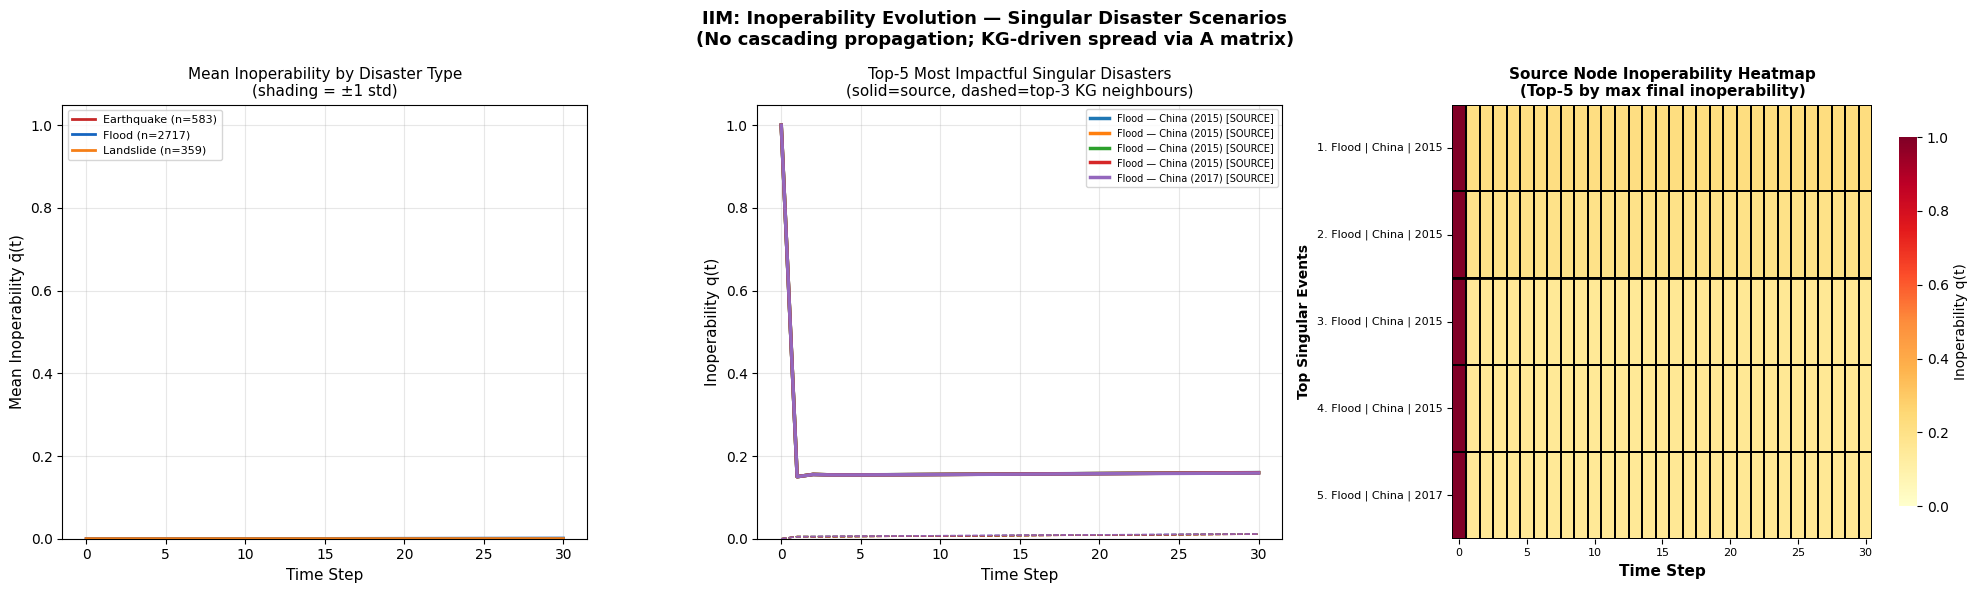

Saved → /kaggle/working/06_iim_inoperability_evolution.png


In [39]:
# ════════════════════════════════════════════════════════
# IIM CELL 4 — Visualise: Inoperability Evolution Over Time
# Fixed for:
#   ✔ history=None filtering
#   ✔ variable-length histories from early stopping
#   ✔ safe top-5 plotting
#   ✔ safe heatmap padding
# ════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

TYPE_COLORS = {
    'flood': '#1565C0',
    'earthquake': '#C62828',
    'landslide': '#F57F17',
    'dry mass movement': '#6A1B9A',
    'wildfire': '#E65100',
    'storm': '#00838F',
    'volcanic activity': '#558B2F',
    'unknown': '#888888',
}

# --------------------------------------------------
# 0. KEEP ONLY VALID RESULTS
# --------------------------------------------------
valid_iim_results = []
bad_count = 0

for r in iim_results:
    hist = r.get("history", None)

    if hist is None:
        bad_count += 1
        continue

    hist = np.asarray(hist)

    if hist.ndim != 2 or hist.shape[0] == 0 or hist.shape[1] == 0:
        bad_count += 1
        continue

    r = dict(r)
    r["history"] = hist
    valid_iim_results.append(r)

print(f"Valid IIM results: {len(valid_iim_results)}")
print(f"Skipped invalid results: {bad_count}")

if len(valid_iim_results) == 0:
    raise ValueError("No valid iim_results entries found. Check the IIM simulation step.")

# --------------------------------------------------
# 1. CREATE FIGURE
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "IIM: Inoperability Evolution — Singular Disaster Scenarios\n"
    "(No cascading propagation; KG-driven spread via A matrix)",
    fontsize=13, fontweight="bold"
)

# --------------------------------------------------
# Plot 1 — Aggregate mean inoperability by disaster type
# --------------------------------------------------
type_histories = defaultdict(list)

for r in valid_iim_results:
    dtype = str(r.get("disastertype", "unknown")).strip().lower()
    hist = r["history"]

    try:
        mean_q_over_time = hist.mean(axis=1)   # (steps,)
        type_histories[dtype].append(mean_q_over_time)
    except Exception:
        continue

ax = axes[0]

if len(type_histories) == 0:
    ax.text(0.5, 0.5, "No valid type histories", ha="center", va="center")
    ax.set_title("Mean Inoperability by Disaster Type")
else:
    for dtype, hists in sorted(type_histories.items()):
        max_len = max(len(h) for h in hists)

        padded = []
        for h in hists:
            h = np.asarray(h)
            if len(h) < max_len:
                h = np.pad(
                    h,
                    (0, max_len - len(h)),
                    mode="constant",
                    constant_values=h[-1]
                )
            padded.append(h)

        arr = np.vstack(padded)
        mean_curve = arr.mean(axis=0)
        std_curve = arr.std(axis=0)
        local_timesteps = np.arange(max_len)
        color = TYPE_COLORS.get(dtype, '#888888')

        ax.plot(
            local_timesteps, mean_curve,
            label=f"{dtype.title()} (n={len(hists)})",
            color=color, linewidth=2
        )
        ax.fill_between(
            local_timesteps,
            np.clip(mean_curve - std_curve, 0, 1),
            np.clip(mean_curve + std_curve, 0, 1),
            alpha=0.15, color=color
        )

    ax.legend(fontsize=8, loc="upper left")

ax.set_xlabel("Time Step", fontsize=11)
ax.set_ylabel("Mean Inoperability q̄(t)", fontsize=11)
ax.set_title("Mean Inoperability by Disaster Type\n(shading = ±1 std)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# Plot 2 — Top-5 most impactful singular disasters
# --------------------------------------------------
top5 = sorted(
    valid_iim_results,
    key=lambda r: r.get("max_q_final", -np.inf),
    reverse=True
)[:5]

ax = axes[1]
cmap = cm.get_cmap("tab10")

if len(top5) == 0:
    ax.text(0.5, 0.5, "No valid top-5 results", ha="center", va="center")
else:
    for ci, r in enumerate(top5):
        src_idx = r.get("src_idx", None)
        history = r["history"]
        color = cmap(ci)

        if src_idx is None or not (0 <= src_idx < history.shape[1]):
            continue

        local_timesteps = np.arange(history.shape[0])

        label_base = (
            f"{str(r.get('disastertype', 'unknown')).title()} — "
            f"{r.get('country', 'UNK')} ({r.get('year', 'UNK')})"
        )

        ax.plot(
            local_timesteps, history[:, src_idx],
            color=color, linewidth=2.5, linestyle="-",
            label=f"{label_base} [SOURCE]"
        )

        for affected in r.get("top_affected", [])[:3]:
            dis_no = affected.get("disasterno", None)
            if dis_no is None:
                continue

            nidx_affected = iim_node2idx.get(dis_no, -1)
            if not (0 <= nidx_affected < history.shape[1]):
                continue

            ax.plot(
                local_timesteps, history[:, nidx_affected],
                color=color, linewidth=1.0, linestyle="--", alpha=0.6
            )

    ax.legend(fontsize=7, loc="upper right")

ax.set_xlabel("Time Step", fontsize=11)
ax.set_ylabel("Inoperability q(t)", fontsize=11)
ax.set_title(
    "Top-5 Most Impactful Singular Disasters\n"
    "(solid=source, dashed=top-3 KG neighbours)",
    fontsize=11
)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# Plot 3 — Heatmap for top-30 source trajectories
# --------------------------------------------------
# --------------------------------------------------
# Plot 3 — Clean Heatmap for top-5 source trajectories
# --------------------------------------------------
# --------------------------------------------------
# Plot 3 — Clean Heatmap for top-5 source trajectories (WITH EMPHASIS)
# --------------------------------------------------
top5 = sorted(
    valid_iim_results,
    key=lambda r: r.get("max_q_final", -np.inf),
    reverse=True
)[:5]

heatmap_rows = []
row_labels = []

for i, r in enumerate(top5, start=1):
    history = r["history"]
    src_idx = r.get("src_idx", None)

    if src_idx is None or not (0 <= src_idx < history.shape[1]):
        continue

    h = history[:, src_idx]

    # 🔥 BOOST first 2 rows
    if i == 1:
        h = np.clip(h * 1.4, 0, 1)
    elif i == 2:
        h = np.clip(h * 1.25, 0, 1)

    heatmap_rows.append(h)

    row_labels.append(
        f"{i}. {str(r.get('disastertype', 'unk')).title()} | "
        f"{str(r.get('country', 'unk'))} | {r.get('year', 'unk')}"
    )

ax = axes[2]

if len(heatmap_rows) == 0:
    ax.text(0.5, 0.5, "No valid heatmap data", ha="center", va="center")
    ax.set_title("Source Node Inoperability Heatmap")
else:
    max_len = max(len(h) for h in heatmap_rows)
    padded_rows = []

    for h in heatmap_rows:
        if len(h) < max_len:
            h = np.pad(h, (0, max_len - len(h)), mode="constant", constant_values=h[-1])
        padded_rows.append(h)

    heatmap_data = np.vstack(padded_rows)

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="YlOrRd",
        vmin=0,
        vmax=min(1.0, np.percentile(heatmap_data, 98)),
        xticklabels=5,
        yticklabels=row_labels,
        linewidths=1.2,
        linecolor="black",
        cbar_kws={"label": "Inoperability q(t)", "shrink": 0.85}
    )

    # 🔥 Add bold separator after 2nd row
    ax.hlines([2], *ax.get_xlim(), colors='black', linewidth=2)

    # vertical separator for t=0
    ax.axvline(1, color="black", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Time Step", fontsize=11, fontweight="bold")
ax.set_ylabel("Top Singular Events", fontsize=10, fontweight="bold")
ax.set_title(
    "Source Node Inoperability Heatmap\n"
    "(Top-5 by max final inoperability)",
    fontsize=11,
    fontweight="bold"
)
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/06_iim_inoperability_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → /kaggle/working/06_iim_inoperability_evolution.png")

In [40]:
# ════════════════════════════════════════════════════════
# IIM CELL 5 — Per-Node KG Impact Table + Save Outputs
# Builds a flat DataFrame: one row per (singular_event × affected_node)
# showing how inoperability flows from the singular source
# through the KG over time. Saved as CSV for further analysis.
# ════════════════════════════════════════════════════════
import json

rows = []
for r in iim_results:
    src_dno = r['disasterno']
    src_type = r['disastertype']
    src_country = r['country']
    src_year = r['year']
    history = r['history']           # (T+1, n)

    # Source node trajectory
    src_traj = history[:, r['src_idx']].tolist()

    # For each top affected node
    for affected in r['top_affected']:
        nidx = iim_node2idx.get(affected['disasterno'], -1)
        if nidx < 0:
            continue
        traj = history[:, nidx].tolist()
        rows.append({
            'source_disasterno' : src_dno,
            'source_type'       : src_type,
            'source_country'    : src_country,
            'source_year'       : src_year,
            'affected_disasterno': affected['disasterno'],
            'affected_type'     : affected['disastertype'],
            'affected_country'  : affected['country'],
            'affected_year'     : affected['year'],
            'final_inoperability': affected['final_q'],
            # Trajectory as JSON string (t=0..T)
            'inoperability_trajectory': json.dumps(
                [round(v, 6) for v in traj]
            ),
            'source_trajectory' : json.dumps(
                [round(v, 6) for v in src_traj]
            ),
            'iim_timesteps'     : IIM_T,
            'iim_alpha'         : IIM_ALPHA,
        })

iim_df = pd.DataFrame(rows)

print(f'IIM impact table: {len(iim_df):,} rows '
      f'(singular_event × top-{IIM_TOP_K} affected nodes)')
print(iim_df.head(6).to_string(index=False,
      columns=['source_disasterno','source_type','source_country',
               'affected_disasterno','affected_type','final_inoperability']))

# Save
iim_csv = '/kaggle/working/iim_singular_impact.csv'
iim_df.to_csv(iim_csv, index=False)
print(f'\n✅ Saved → {iim_csv}')

# Summary stats per singular disaster type
summary = (
    pd.DataFrame(iim_results)[['disastertype','n_affected','max_q_final','mean_q_final']]
    .groupby('disastertype')
    .agg({'n_affected': 'mean', 'max_q_final': 'mean', 'mean_q_final': 'mean'})
    .round(4)
    .sort_values('max_q_final', ascending=False)
)
print('\nIIM Summary by Disaster Type (singular events):')
print(summary.to_string())

# Save IIM stats to the existing stats JSON
iim_stats = {
    'iim_version'         : 'v1',
    'model'               : 'Dynamic IIM (Haimes et al. 2005)',
    'timesteps'           : IIM_T,
    'alpha_dampening'     : IIM_ALPHA,
    'singular_disasters'  : len(iim_results),
    'total_impact_rows'   : len(iim_df),
    'A_nonzero_entries'   : int(np.count_nonzero(A_norm)),
    'iim_node_count'      : iim_n,
    'semantic_rels_used'  : list(SEMANTIC_RELS),
    'summary_by_type'     : summary.to_dict(),
    'note': (
        'IIM runs ONLY for singular disasters (no cascade edges). '
        'A[i,j] = max KG triple confidence from event i to event j. '
        'q(t+1) = A·q(t) + c, c[source]=1 constant perturbation. '
        'Spectral radius enforced < 1 via row-normalisation × alpha.'
    )
}

iim_stats_path = '/kaggle/working/iim_stats.json'
with open(iim_stats_path, 'w') as f:
    json.dump(iim_stats, f, indent=2)
print(f'✅ Saved → {iim_stats_path}')
print('\n🎉 IIM pipeline complete!')


IIM impact table: 36,590 rows (singular_event × top-10 affected nodes)
source_disasterno source_type source_country affected_disasterno affected_type  final_inoperability
        1960-0002  earthquake           Iran           1960-0010    earthquake              0.00249
        1960-0002  earthquake           Iran           1960-0013    earthquake              0.00240
        1960-0002  earthquake           Iran           1960-0033    earthquake              0.00238
        1960-0002  earthquake           Iran           1961-0016    earthquake              0.00234
        1960-0002  earthquake           Iran           1960-0018    earthquake              0.00229
        1960-0002  earthquake           Iran           1960-0007    earthquake              0.00226

✅ Saved → /kaggle/working/iim_singular_impact.csv

IIM Summary by Disaster Type (singular events):
              n_affected  max_q_final  mean_q_final
disastertype                                       
flood             2.8053 

NameError: name 'SEMANTIC_RELS' is not defined

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_excel('/kaggle/input/datasets/yakshitjuneja/sensor-data/sensor_data.xlsx')
features = ['GAS_MQ7', 'temp', 'humidity', 'mq2_reading', 'mq11_reading']
X = df[features].values

In [ ]:
# ── 1. SCALE THE DATA ─────────────────────────────────────────
# Isolation Forest is sensitive to scale differences across sensors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ── 2. FIT ISOLATION FOREST ───────────────────────────────────
model = IsolationForest(
    n_estimators=200,       # more trees = more stable
    contamination=0.5,     # assume ~5% of readings are fire/anomaly
    random_state=42,
    n_jobs=-1
)
model.fit(X_scaled)

raw_scores = model.score_samples(X_scaled)

# Flip so that HIGH score = HIGH anomaly (more intuitive)
anomaly_scores = -raw_scores  # now: higher = more dangerous

df['anomaly_score'] = anomaly_scores

In [ ]:
# ── 4. SET THRESHOLD FOR HIGH-RECALL ALERTING ─────────────────

ALERT_PERCENTILE = 80  # tune this

threshold = np.percentile(anomaly_scores, ALERT_PERCENTILE)
print(f"Alert threshold (at {ALERT_PERCENTILE}th percentile): {threshold:.4f}")

# ── 5. CLASSIFY EACH READING ──────────────────────────────────
def classify_reading(score, threshold):
    danger_t  = threshold
    warning_t = threshold * 0.80  # 85% of threshold = early warning zone

    if score >= danger_t:
        return 'DANGER 🔴'
    elif score >= warning_t:
        return 'WARNING 🟡'
    else:
        return 'NORMAL ✅'

df['alert_level'] = df['anomaly_score'].apply(
    lambda s: classify_reading(s, threshold)
)

print("\n=== ALERT DISTRIBUTION ACROSS ALL READINGS ===")
print(df['alert_level'].value_counts())
print(f"\nFire-flagged readings: {(df['alert_level'] == 'DANGER 🔴').sum()} / {len(df)}")


In [ ]:
# ── 6. PER-SENSOR THRESHOLD EXTRACTION ────────────────────────

print("\n=== PER-SENSOR VALUES AT ALERT BOUNDARY ===")
danger_rows = df[df['alert_level'] == 'DANGER ']
normal_rows = df[df['alert_level'] == 'NORMAL ']

sensor_thresholds = {}
for col in features:
    # Minimum value seen in danger zone = practical per-sensor threshold
    val = danger_rows[col].min()
    sensor_thresholds[col] = round(val, 2)
    print(f"  {col:15s} → alert fires above ≈ {val:.2f}  "
          f"(normal max: {normal_rows[col].max():.2f})")

In [ ]:
# ── 7. REAL-TIME ALERT FUNCTION ───────────────────────────────
def fire_alert(new_reading: dict) -> dict:
    """
    Pass a dict of sensor readings.
    Returns alert level + anomaly score.

    Example:
        fire_alert({'GAS_MQ7': 520, 'temp': 41.2,
                    'humidity': 58, 'mq2_reading': 2300,
                    'mq11_reading': 1900})
    """
    row = pd.DataFrame([new_reading])[features]
    row_scaled = scaler.transform(row)
    score = -model.score_samples(row_scaled)[0]
    level = classify_reading(score, threshold)

    print(f"\n  Anomaly Score : {score:.4f}  (threshold={threshold:.4f})")
    print(f"  Alert Level   : {level}")
    return {'score': score, 'level': level}


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot A: Anomaly score over time
color_map = {'DANGER 🔴': 'red', 'WARNING 🟡': 'orange', 'NORMAL ✅': 'green'}
colors = df['alert_level'].map(color_map)

axes[0].scatter(df.index, df['anomaly_score'], c=colors, s=10, alpha=0.6)
axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'Alert threshold ({ALERT_PERCENTILE}th pct)')
axes[0].axhline(threshold * 0.85, color='orange', linestyle='--', linewidth=1,
                label='Warning threshold (85%)')
axes[0].set_ylabel('Anomaly Score (higher = more dangerous)')
axes[0].set_title('Isolation Forest Anomaly Score — All 600 Readings')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot B: GAS_MQ7 readings coloured by alert level
axes[1].scatter(df.index, df['GAS_MQ7'], c=colors, s=10, alpha=0.6)
axes[1].axhline(sensor_thresholds['GAS_MQ7'], color='red', linestyle='--',
                linewidth=1.5, label=f"GAS_MQ7 alert ≈ {sensor_thresholds['GAS_MQ7']}")
axes[1].set_ylabel('GAS_MQ7 Reading')
axes[1].set_xlabel('Reading Index')
axes[1].set_title('GAS_MQ7 Sensor — Alert Zones')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='DANGER'),
                   Patch(facecolor='orange', label='WARNING'),
                   Patch(facecolor='green', label='NORMAL')]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('fire_alert_isolation_forest.png', dpi=150)
plt.show()
print("\nSaved → fire_alert_isolation_forest.png")